# Heavy Equipment Selling Price Prediction Challenge

## MLP Project 2026 T2

### IIT Madras BS Degree in Data Science and Applications

## Problem Statement
This dataset provides comprehensive operational, transactional, and technical insights into how a global platform tracks, structures, and processes heavy industrial machinery and equipment lifecycles. Each record in the dataset captures a single, finalised accounting or operational event, complete with system metadata, geographic indicators, deep component specifications, and mechanical configurations.

**The goal is to explore this rich multi-modal dataset, discover latent patterns across numerical, categorical, and high-cardinality technical string features, and build robust predictive models to forecast the target financial or operational variable.**


## Objective

Predict the selling price of heavy industrial machinery using classical machine learning techniques.

The notebook follows a complete machine learning workflow, including:

- Exploratory Data Analysis (EDA)
- Train-Validation Split
- Feature Engineering
- Pre-processing
- Multiple model comparison
- Hyperparameter tuning
- Error analysis
- Final Kaggle submission

The competition evaluation metric is **Root Mean Squared Logarithmic Error (RMSLE)**.


# Imports

In [1]:
# Heavy Equipment Selling Price Prediction Challenge
# --------------------------------------------------------------------------------------- #

# Imports
# --------------------------------------------------------------------------------------- #

# Standard Libraries
# ----------------------------
import os
os.environ["PYTHONWARNINGS"] = "ignore::UserWarning"

# Data Analysis
# ----------------------------
import numpy as np
import pandas as pd 

# Visualization
# ----------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
# ----------------------------
from scipy import stats 
from scipy.stats import spearmanr

# Scikit-Learn Utilities
# ----------------------------
#Train-test splitting
from sklearn.model_selection import (train_test_split,GridSearchCV,cross_val_score)

# Pre-processing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# ----------------------------
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Models
# ----------------------------
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Tuning
# ----------------------------
from sklearn.model_selection import GridSearchCV

# Metrics
# ----------------------------
from sklearn.metrics import root_mean_squared_log_error,mean_squared_error,mean_absolute_error,r2_score

#for gridsearch use of RMSLE
from sklearn.metrics import make_scorer


# Load Datasets

In [2]:
# Load Datasets
# --------------------------------------------------------------------------------------- #

# loading the training, metadata and test datasets
# ----------------------------
train_df = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv",low_memory=False)
test_df = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv",low_memory=False)
meta_df = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv")

# loading the sample_submission dataset
# ----------------------------
sample = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv")

The competition provides four files:

- **train.csv** – Training dataset containing the target variable
- **test.csv** – Test dataset for which predictions must be generated
- **metadata.csv** – Description of every feature in the dataset
- **sample_submission.csv** – Example submission format

#  Dataset Overview

Before performing any preprocessing or model building, we inspect the datasets to understand their structure, feature types, quality of dataset, and overall characteristics first.

## Dataset Dimensions

In [3]:
# Dataset dimensions
# --------------------------------------------------------------------------------------- #
print("Training dataset shape: ",train_df.shape)
print("Test dataset shape: ",test_df.shape)
print("Metadata shape: ",meta_df.shape)

Training dataset shape:  (138701, 50)
Test dataset shape:  (15000, 49)
Metadata shape:  (50, 2)


Dataset dimensions (rows, columns):

Training dataset shape:  **(138701, 50)**

Test dataset shape:  **(15000, 49)**

Metadata shape:  **(50, 2)**

Initial Observations:

The test dataset has one missing column, which is likely the target column present in the training dataset.

The metadata has the same number of rows as the number of columns in the training dataset and only two columns.

## Training Dataset Preview

In [4]:
train_df.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


## Training Dataset information

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

## Training Dataset Basic Statistical Information

In [6]:
train_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TransactionID,138701.0,NaN,NaN,NaN,2186275.950556,1128496.619347,1139309.0,1465754.0,1751884.0,2372139.0,6333410.0
TargetValue,138701.0,NaN,NaN,NaN,41521.874047,26361.125948,7500.0,20500.0,35000.0,57000.0,142000.0
AssetID,138701.0,NaN,NaN,NaN,1204814.320423,528737.593449,8.0,1007930.0,1246956.0,1495817.0,2478476.0
ProductConfigID,138701.0,NaN,NaN,NaN,7286.421922,7542.421537,39.0,1693.0,3852.0,11873.0,37209.0
DataOriginCode,138701,6,ADI149,59541,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VendorPartnerID,138701,31,UJF,67828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ManufactureYear,138701.0,NaN,NaN,NaN,1891.640853,306.992001,1001.0,1990.0,1998.0,2004.0,2015.0
OperationalHoursMeter,82058.0,NaN,NaN,NaN,4553.718943,27922.04485,0.0,0.0,1620.0,5001.0,1729600.0
UtilizationTier,50475,3,Medium,24588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TransactionDate,138701,3676,2010-02-16,1159,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Observations from the Training Dataset

- The training dataset contains **138,701 rows** and **50 columns**.
- The dataset consists of **44 object (categorical)** features, **4 integer** features and **2 float** features.
- `OperationalHoursMeter` contains **82,058** non-null values (about 41% missing).
- `UtilizationTier` contains **50,475** non-null values (about 64% missing).
- `ManufactureYear` ranges from **1001** to **2015**, indicating the presence of anomalous values.
- `OperationalHoursMeter` ranges from **0** to **1,729,600**, with a median of **1,620**, suggesting a highly right-skewed distribution.
- `TargetValue` ranges from **7,500** to **142,000**, with a median of **35,000** and mean of **41,521.87**, indicating possible positive skew.

## Test Dataset Preview

In [7]:
test_df.head()

,TransactionID,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,Spec_FullDescriptor,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139307,999097,3168,ACH138,GTX,2005,68.0,Low,2007-11-16,521D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139419,1018084,1344,ACH138,GTX,1999,10466.0,Medium,2007-06-01,345BL,...,Steel,None or Unspecified,"15' 9""",None or Unspecified,Yes,Double,NaN,NaN,NaN,NaN
2,1139482,1048712,2808,ACH138,GTX,2001,3817.0,Low,2012-06-16,EX120-5,...,Steel,None or Unspecified,None or Unspecified,Hydraulic,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139522,697537,1089,ACH138,GTX,2006,1498.0,Medium,2010-08-27,304CR,...,Rubber,16 inch,None or Unspecified,Manual,Yes,Double,NaN,NaN,NaN,NaN
4,1139684,1048082,16781,ACH138,GTX,2009,22.0,Low,2010-07-09,L2800D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Test Dataset information

In [8]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 49 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   TransactionID              15000 non-null  int64  
 1   AssetID                    15000 non-null  int64  
 2   ProductConfigID            15000 non-null  int64  
 3   DataOriginCode             15000 non-null  object 
 4   VendorPartnerID            15000 non-null  object 
 5   ManufactureYear            15000 non-null  int64  
 6   OperationalHoursMeter      8809 non-null   float64
 7   UtilizationTier            5356 non-null   object 
 8   TransactionDate            15000 non-null  object 
 9   Spec_FullDescriptor        15000 non-null  object 
 10  Spec_BaseClass             15000 non-null  object 
 11  Spec_SubClass              11006 non-null  object 
 12  Spec_ReleaseSeries         3505 non-null   object 
 13  Spec_VariantModifier       5609 non-null   obj

## Test Dataset Overview

The test dataset contains the unseen data on which the final predictions will be generated and submitted to the competition.

Unlike the training dataset, it does **not** contain the target variable (`TargetValue`), as this is what our machine learning models are expected to predict after training.

The initial overview is to verify that the feature structure, data types and overall format are consistent with the training dataset before building the machine learning pipeline.

## Training Label Column

Training Label column is : **TargetValue**

In [9]:
print(set(train_df.columns) - set(test_df.columns))

{'TargetValue'}


### Observations from the Test Dataset

- The testing dataset contains **15,000 rows** and **49 columns**.
- The test dataset contains the same predictor features as the training dataset, with the only missing column being **`TargetValue`**.
- Similar to the training dataset, the majority of the features(44) are of **object (categorical)** data type.
- The missing value pattern appears similar to the training dataset, suggesting that the same pre-processing strategies can be fitted later to both datasets.
- The data types of the feature columns are consistent with those observed in the training dataset.

## Metadata Overview

The competition provides a metadata file describing the purpose of every feature present in the dataset.

Although the original dataset contains several generic column names (such as `col1`, `col3` etc.).

The metadata provides meaningful descriptions that will help interpret these variables.

Understanding the metadata is essential for:
- interpreting anonymous features,
- identifying identifier, numerical, categorical and temporal features,
- improving feature engineering decisions,
- and improving the quality of the machine learning pipeline.

### Metadata dimensions

In [10]:
meta_df.shape

(50, 2)

### Metadata preview

In [11]:
meta_df.head(10)

,Variable,Rephrased Description
0,TransactionID,A unique serial number assigned to each indivi...
1,TargetValue,"The financial amount of the transaction, denom..."
2,AssetID,The internal tracking number assigned to a spe...
3,ProductConfigID,A system-generated code representing the techn...
4,DataOriginCode,A code indicating the specific software or pla...
5,VendorPartnerID,The unique ID of the external entity or third-...
6,TransactionDate,The official calendar date when the entry was ...
7,RegionCode,The specific geographic area or legal jurisdic...
8,ManufactureYear,The year the asset was originally produced.
9,OperationalHoursMeter,The lifetime total of active run-time or work ...


In [12]:
meta_df.tail(10)

,Variable,Rephrased Description
40,col20,The specific tread or surface pattern of the t...
41,col21,The width of the surface area that makes conta...
42,col22,The maximum reach or length of the operational...
43,col23,The design of the interface used to hold or re...
44,col24,The configuration map for the machine’s contro...
45,col25,The specific profile or shape of the traction ...
46,col27,The specific design or category of the attache...
47,col28,The configuration of the operator's directiona...
48,col29,The type of differential used for power distri...
49,col30,The primary interface used by the operator for...


### Metadata Observations

- The metadata file contains **50 rows** and **2 columns**, corresponding to the features and their descriptions.
- Each feature in the dataset is accompanied by a `Rephrased Description` explaining its operational or mechanical meaning.
- The columns with generic names (`col1`, `col3`, ..., `col30`) represent specific engineering or machine configuration properties rather than arbitrary variables.



- The metadata will be used throughout the notebook to better understand feature semantics and improve feature engineering decisions.

# Initial Dataset Understanding

Based on the initial inspection of the training dataset, testing dataset and metadata, the following observations can be made:

### Dataset Structure
- The training dataset contains **138,701 rows** and **50 columns**, while the test dataset contains **15,000 rows** and **49 columns**.
- The only column missing from the test dataset is the target variable **`TargetValue`**, which is expected for a supervised learning competition.
- Both datasets contain a large number of categorical features (**44 object-type columns**), along with a small number of numerical features.

### Data Quality
- Several features contain substantial missing values, particularly `OperationalHoursMeter`, `UtilizationTier`, and many machine configuration columns.
- `ManufactureYear` contains anomalous values (minimum = **1001**) which will require further investigation before modelling.
- `TransactionDate` is currently stored as an object and will need to be converted to a datetime datatype before extracting temporal information.

### Numerical Features
- `OperationalHoursMeter` ranges from **0** to **1,729,600**, with a median of **1,620**, indicating a highly right-skewed distribution and the presence of potential outliers.
- The target variable `TargetValue` ranges from **7,500** to **142,000**. Its mean (**41,521.87**) is higher than its median (**35,000**), suggesting a positively skewed distribution.

### Categorical Features
- The dataset contains several high-cardinality categorical variables such as `Spec_FullDescriptor`, `Spec_BaseClass`, `Spec_SubClass`, `Spec_ReleaseSeries`, and `Spec_VariantModifier`.
- Other categorical variables such as `CabinType` and `UtilizationTier` contain relatively few categories and may require different preprocessing strategies.

### Metadata
- The metadata provides semantic descriptions for every feature in the dataset, including the generic machine configuration columns (`col1`to `col30`).
- These descriptions will be used throughout the project to guide feature engineering, preprocessing decisions and interpretation of the machine learning models.


# Feature Inventory

Before performing feature engineering or pre-processing, we classify each feature according to its role in the machine learning pipeline.

This structured inventory helps document every variable and provides clarity for subsequent pre-processing, feature engineering and model decisions.

In [13]:
# feature inventory
# ------------------------------------------------------------ #
feature_inventory = pd.DataFrame({
    "Feature": train_df.columns,
    "Data Type": train_df.dtypes.astype(str).values,
    "Missing Values": train_df.isna().sum().values,
    "Missing (%)": (train_df.isna().mean() * 100).round(2).values,
    "Unique Values": train_df.nunique().values
})

# metadata dictionary
metadata_map = dict(zip(meta_df["Variable"], meta_df["Rephrased Description"]))

# add metadata to feature inventory
feature_inventory["Metadata"] = feature_inventory["Feature"].map(metadata_map)

# to remove column width restriction to read the entire metadata per row
pd.set_option('display.max_colwidth', None)

feature_inventory

,Feature,Data Type,Missing Values,Missing (%),Unique Values,Metadata
0,TransactionID,int64,0,0.00,138701,A unique serial number assigned to each individual accounting record.
1,TargetValue,float64,0,0.00,675,"The financial amount of the transaction, denominated in US Dollars."
2,AssetID,int64,0,0.00,120111,The internal tracking number assigned to a specific piece of hardware.
3,ProductConfigID,int64,0,0.00,3594,A system-generated code representing the technical build-out of the unit.
4,DataOriginCode,object,0,0.00,6,A code indicating the specific software or platform where the data originated.
5,VendorPartnerID,object,0,0.00,31,The unique ID of the external entity or third-party provider involved.
6,ManufactureYear,int64,0,0.00,68,The year the asset was originally produced.
7,OperationalHoursMeter,float64,56643,40.84,14643,The lifetime total of active run-time or work cycles logged by the machine.
8,UtilizationTier,object,88226,63.61,3,"A ranking (Low, Medium, or High) based on how heavily the asset is used."
9,TransactionDate,object,0,0.00,3676,The official calendar date when the entry was finalized in the system.


In [14]:
feature_inventory["Category"] = ""
feature_inventory["Initial Decision"] = ""

In [15]:
category_map = {

    "TransactionID":"Transaction Identifier",
    "TargetValue":"Regression Target",
    "AssetID":"Machine Identifier",
    "ProductConfigID":"High-cardinality Configuration",
    "DataOriginCode":"Nominal Categorical",
    "VendorPartnerID":"Nominal Categorical",

    "ManufactureYear":"Numerical (Temporal)",
    "OperationalHoursMeter":"Numerical",
    "UtilizationTier":"Ordinal Categorical",
    "TransactionDate":"Datetime",
    "Spec_FullDescriptor":"High-cardinality Technical Feature",

    "Spec_BaseClass":"High-cardinality Technical Category",
    "Spec_SubClass":"High-cardinality Technical Category",
    "Spec_ReleaseSeries":"Technical Category",
    "Spec_VariantModifier":"Technical Category",
    "AssetScaleFactor":"Machine Size Category",

    "FunctionalClassification":"Nominal Categorical",
    "RegionCode":"Nominal Categorical",
    "InventoryGroupCategory":"Nominal Categorical",
    "InventoryGroupDescription":"Nominal Categorical",

    "CabinType":"Machine Configuration",
    "Forks":"Machine Attachment",
    "DrivetrainType":"Machine Configuration"
}

In [16]:
feature_inventory["Category"] = (feature_inventory["Feature"].map(category_map))

In [17]:
decision_map = {

    "TransactionID":"Exclude from model",
    "TargetValue":"Predict",

    "AssetID":"Investigate",

    "ProductConfigID":"Keep & Investigate",
    "DataOriginCode":"Keep & Investigate",
    "VendorPartnerID":"Keep & Investigate",

    "ManufactureYear":"Keep",
    "OperationalHoursMeter":"Keep",
    "UtilizationTier":"Keep",
    "TransactionDate":"Engineer",
    "Spec_FullDescriptor":"Investigate",

    "Spec_BaseClass":"Keep",
    "Spec_SubClass":"Keep",
    "Spec_ReleaseSeries":"Keep & Investigate",
    "Spec_VariantModifier":"Keep & Investigate",
    "AssetScaleFactor":"Keep",

    "FunctionalClassification":"Keep",
    "RegionCode":"Keep",
    "InventoryGroupCategory":"Keep",
    "InventoryGroupDescription":"Investigate",

    "CabinType":"Keep",
    "Forks":"Keep",
    "DrivetrainType":"Keep"
}

In [18]:
feature_inventory["Initial Decision"] = (feature_inventory["Feature"].map(decision_map))

In [19]:
feature_inventory["Category"] = feature_inventory["Category"].fillna("Engineering Specification")

feature_inventory["Initial Decision"] = feature_inventory["Initial Decision"].fillna("Investigate")

In [20]:
feature_inventory

,Feature,Data Type,Missing Values,Missing (%),Unique Values,Metadata,Category,Initial Decision
0,TransactionID,int64,0,0.00,138701,A unique serial number assigned to each individual accounting record.,Transaction Identifier,Exclude from model
1,TargetValue,float64,0,0.00,675,"The financial amount of the transaction, denominated in US Dollars.",Regression Target,Predict
2,AssetID,int64,0,0.00,120111,The internal tracking number assigned to a specific piece of hardware.,Machine Identifier,Investigate
3,ProductConfigID,int64,0,0.00,3594,A system-generated code representing the technical build-out of the unit.,High-cardinality Configuration,Keep & Investigate
4,DataOriginCode,object,0,0.00,6,A code indicating the specific software or platform where the data originated.,Nominal Categorical,Keep & Investigate
5,VendorPartnerID,object,0,0.00,31,The unique ID of the external entity or third-party provider involved.,Nominal Categorical,Keep & Investigate
6,ManufactureYear,int64,0,0.00,68,The year the asset was originally produced.,Numerical (Temporal),Keep
7,OperationalHoursMeter,float64,56643,40.84,14643,The lifetime total of active run-time or work cycles logged by the machine.,Numerical,Keep
8,UtilizationTier,object,88226,63.61,3,"A ranking (Low, Medium, or High) based on how heavily the asset is used.",Ordinal Categorical,Keep
9,TransactionDate,object,0,0.00,3676,The official calendar date when the entry was finalized in the system.,Datetime,Engineer


## Feature Inventory Summary

The feature inventory combines dataset statistics with the competition metadata to create an initial understanding of every variable before preprocessing.

For each feature, the inventory records:

- Data type
- Missing value count and percentage
- Number of unique values
- Metadata description
- Feature category
- Initial modelling decision

The initial decisions are conservative and represent working hypotheses rather than the final preprocessing choices.

Decision categories used throughout the notebook are:

- **Keep** – retain the feature for modelling because it is expected to contain useful predictive information.
- **Engineer** – transform the feature into more informative features during feature engineering.
- **Investigate** – evaluate the feature further during EDA before deciding whether to retain, transform or drop it.
- **Exclude from model** – retain only for submission purposes.

The final preprocessing pipeline will be based on evidence gathered during the subsequent missing value analysis, exploratory data analysis, feature engineering and model evaluation rather than on these initial assumptions.

# Missing Value Analysis

Missing value analysis is performed before preprocessing to understand the extent and patterns of missing data across the dataset.

The objectives of this section are:

- identify features with little or no missing data.
- identify features that require imputation.
- identify features with high a percentage of missing values, which may be removed.
- understand whether missing data of a feature follows any systematic pattern to indicate predictive power.
- gather more evidence for later preprocessing decisions.

In [21]:
# Missing Value Summary
# ------------------------------------------------------------ #

missing_summary = pd.DataFrame({
    "Missing Values": train_df.isnull().sum(),
    "Missing (%)": (train_df.isnull().mean() * 100).round(2)
})

missing_summary = (missing_summary.sort_values("Missing (%)", ascending=False))

missing_summary

,Missing Values,Missing (%)
col19,138635,99.95
col18,138635,99.95
col5,128320,92.52
col4,128320,92.52
col27,123742,89.21
col28,123742,89.21
col29,119829,86.39
col30,119829,86.39
col13,115296,83.13
col14,115296,83.13


## Columns with missing values

In [22]:
# Columns with missing values only
missing_summary[missing_summary["Missing Values"] > 0]

,Missing Values,Missing (%)
col19,138635,99.95
col18,138635,99.95
col5,128320,92.52
col4,128320,92.52
col27,123742,89.21
col28,123742,89.21
col29,119829,86.39
col30,119829,86.39
col13,115296,83.13
col14,115296,83.13


In [23]:
print("Features with >0% missing values:",len(missing_summary[missing_summary["Missing Values"] > 0]))

Features with >0% missing values: 35


### Missing Values Bar Plot

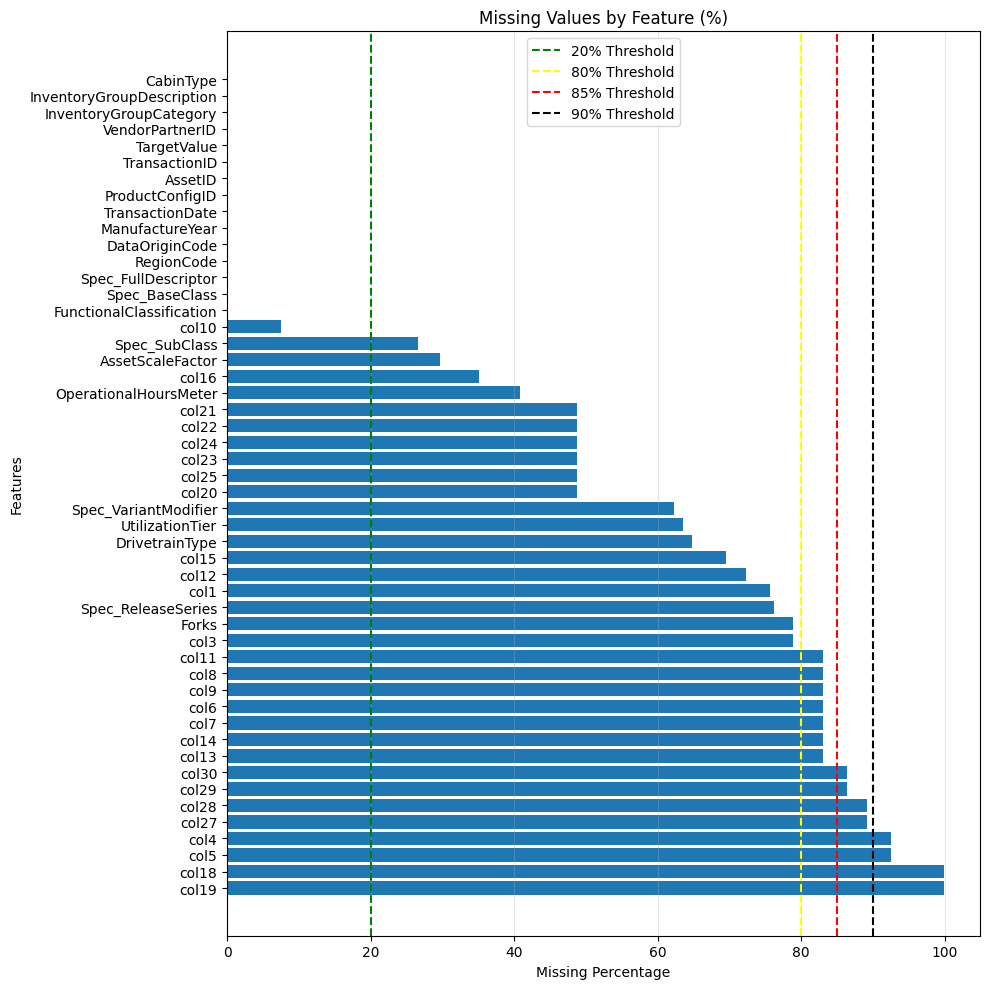

In [24]:
plt.figure(figsize=(10, 10))

plt.barh(
    missing_summary.index,
    missing_summary["Missing (%)"]
)

plt.xlabel("Missing Percentage")
plt.ylabel("Features")
plt.title("Missing Values by Feature (%)")

plt.grid(axis="x", alpha=0.3)

plt.axvline(20, color="green", linestyle="--", label="20% Threshold")
plt.axvline(80, color="yellow", linestyle="--", label="80% Threshold")
plt.axvline(85, color="red", linestyle="--", label="85% Threshold")
plt.axvline(90, color="black", linestyle="--", label="90% Threshold")
plt.legend()

plt.tight_layout()
plt.show()

plt.close()

## Features with high percentage of missing values

In [25]:
# Features with more than 98% missing values
high_missing_val_80 = missing_summary[
    missing_summary["Missing (%)"] > 80
]

print("Features with >80% missing values:", len(high_missing_val_80))
high_missing_val_80

Features with >80% missing values: 15


,Missing Values,Missing (%)
col19,138635,99.95
col18,138635,99.95
col5,128320,92.52
col4,128320,92.52
col27,123742,89.21
col28,123742,89.21
col29,119829,86.39
col30,119829,86.39
col13,115296,83.13
col14,115296,83.13


In [26]:
# Features with more than 85% missing values
high_missing_val_85 = missing_summary[
    missing_summary["Missing (%)"] > 85
]

print("Features with >85% missing values:", len(high_missing_val_85))
high_missing_val_85

Features with >85% missing values: 8


,Missing Values,Missing (%)
col19,138635,99.95
col18,138635,99.95
col5,128320,92.52
col4,128320,92.52
col27,123742,89.21
col28,123742,89.21
col29,119829,86.39
col30,119829,86.39


In [27]:
# Features with more than 90% missing values
high_missing_val_90 = missing_summary[
    missing_summary["Missing (%)"] > 90
]

print("Features with >90% missing values:", len(high_missing_val_90))
high_missing_val_90

Features with >90% missing values: 4


,Missing Values,Missing (%)
col19,138635,99.95
col18,138635,99.95
col5,128320,92.52
col4,128320,92.52


## Features with low percentage of missing values

In [28]:
low_missing_val = missing_summary[
    (missing_summary["Missing (%)"] > 0) &
    (missing_summary["Missing (%)"] < 20)
]

print("Features with <20% missing values:", len(low_missing_val))
low_missing_val

Features with <20% missing values: 1


,Missing Values,Missing (%)
col10,10381,7.48


## Features with no missing values

In [29]:
no_missing_val = missing_summary[
    missing_summary["Missing (%)"] == 0
]

print("Features with no missing values:", len(no_missing_val))
no_missing_val

Features with no missing values: 15


,Missing Values,Missing (%)
FunctionalClassification,0,0.0
Spec_BaseClass,0,0.0
Spec_FullDescriptor,0,0.0
RegionCode,0,0.0
DataOriginCode,0,0.0
ManufactureYear,0,0.0
TransactionDate,0,0.0
ProductConfigID,0,0.0
AssetID,0,0.0
TransactionID,0,0.0


In [30]:

asset_counts = train_df["AssetID"].value_counts()

print(asset_counts.describe())
print("\nUnique Asset IDs:", train_df["AssetID"].nunique())
print("Total rows:", len(train_df))

count    120111.000000
mean          1.154774
std           0.673701
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          46.000000
Name: count, dtype: float64

Unique Asset IDs: 120111
Total rows: 138701


## Missing Value Analysis Observations

The missing value analysis reveals that missingness is not uniformly distributed across the dataset. Instead, it is concentrated within a specific group of engineering configuration features.

### Key observations

- Out of the 50 features in the training dataset, **35 features contain at least one missing value**, while **15 features contain no missing values**.

- The features with **no missing values** mainly consist of identifiers, business information, machine classification variables and the target variable. These features require no missing value treatment.

- Only **one feature (`col10`) contains less than 20% missing values (7.48%)**, making it suitable for imputation during pre-processing.

- **15 features contain more than 80% missing values**, indicating that a large portion of the engineering specification variables are sparsely populated.

- Among these, **four features (`col18`, `col19`, `col4` and `col5`) contain more than 90% missing values**, making them strong candidates for removal unless they signal significant predictive value during feature engineering.

- Several engineering specification features exhibit very high missing percentages. Their missingness appears to follow a common structural pattern of the dataset.

- Although **OperationalHoursMeter** contains approximately **41% missing values**, it represents the lifetime operating hours of the machine and is expected to be an important predictor of selling price. Therefore, it will be retained and appropriately imputed rather than removed.

- **UtilizationTier** contains approximately **64% missing values**. Since it captures machine usage intensity (Low, Medium or High), it will also be retained for further investigation.

### Initial preprocessing direction

At this stage, no feature is removed only based on its missing percentage.

Instead:

- features with little missing data will be imputed,
- features with moderate missingness will be evaluated individually,
- features with extremely high missingness will be investigated further before making a final decision,
- and engineering features will be analysed together with the competition metadata to determine whether the missing values themselves carry useful information.

# Exploratory Data Analysis (EDA)

## Target Variable Analysis

Before building training models, it is important we understand the distribution of the target variable `TargetValue`.

Studying the target variable to answer several questions:

- Is the distribution symmetric or skewed?
- Are there extreme values or outliers?
- Would a transformation improve model performance?
- Does the evaluation metric (RMSLE) suggest transforming the target?

These observations guide preprocessing decisions and help understand model behaviour during it's evaluation.

The findings from this analysis also help justify the use of a log transformation before model training.

### Summary Statistics

In [31]:
target = train_df["TargetValue"]

print("Count :", target.count())
print("Mean :", target.mean())
print("Median :", target.median())
print("Std :", target.std())
print("Minimum :", target.min())
print("Maximum :", target.max())
print("Skewness :", target.skew())
print("Kurtosis :", target.kurt())

Count : 138701
Mean : 41521.87404705085
Median : 35000.0
Std : 26361.12594782802
Minimum : 7500.0
Maximum : 142000.0
Skewness : 0.9699963984208283
Kurtosis : 0.42390608021812515


### Histogram

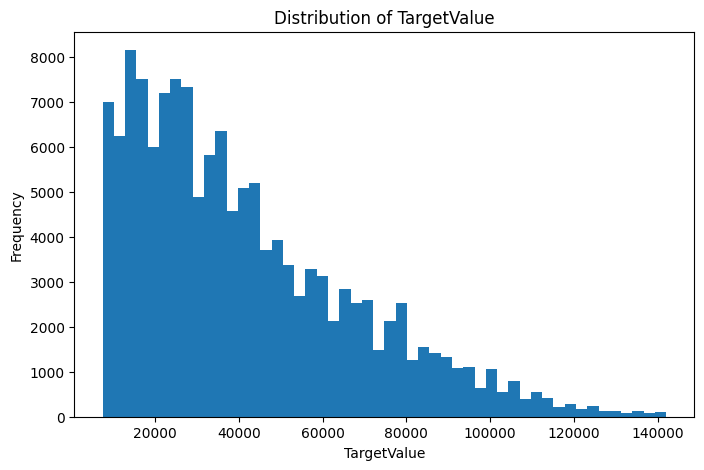

In [32]:
plt.figure(figsize=(8,5))

plt.hist(target, bins=50)

plt.title("Distribution of TargetValue")
plt.xlabel("TargetValue")
plt.ylabel("Frequency")

plt.show()

plt.close()

### Boxplot

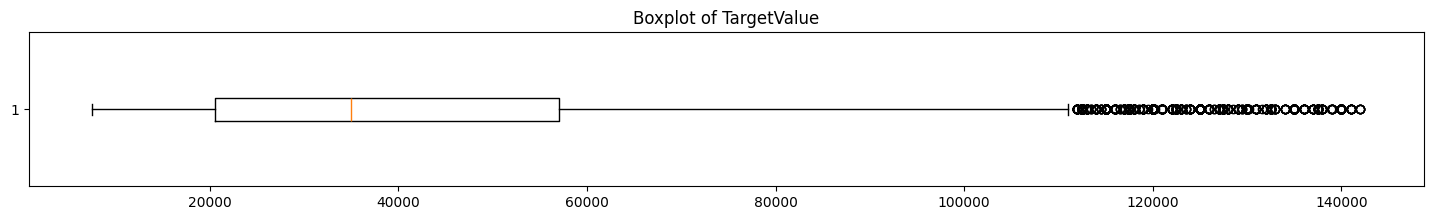

In [33]:
plt.figure(figsize=(18,2))

plt.boxplot(target, vert=False)

plt.title("Boxplot of TargetValue")

plt.show()

### Log Transformation comparison of histogram

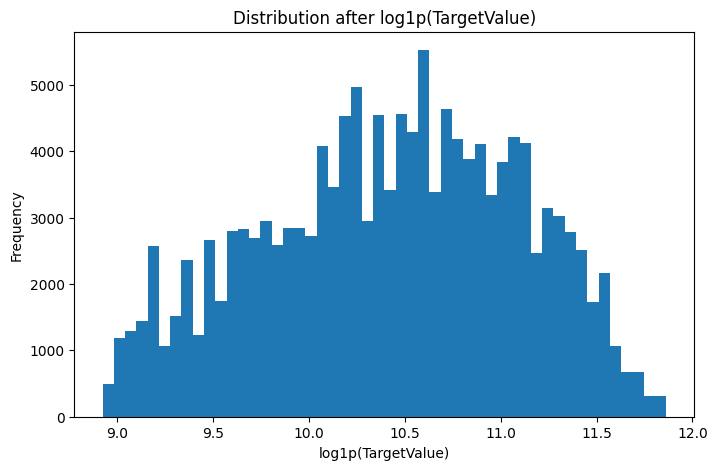

In [34]:
plt.figure(figsize=(8,5))

plt.hist(np.log1p(target), bins=50)

plt.title("Distribution after log1p(TargetValue)")
plt.xlabel("log1p(TargetValue)")
plt.ylabel("Frequency")

plt.show()

plt.close()

### Observations about Target Variable

- The target variable contains **138,701** observations with **no missing values**.
- The **mean (41,521.87)** is greater than the **median (35,000)**, indicating a moderately **right-skewed** distribution.
- The histogram confirms that most transactions correspond to lower and medium-priced equipment, while expensive machines are comparatively rare.
- The boxplot reveals the presence of several high-value observations beyond the upper whisker. These appear to represent very expensive equipment rather than obvious data entry errors.
- The **skewness** value of approximately **0.97** quantitatively confirms the positive skew observed in the histogram.
- Applying a log1p transformation produces a distribution that is substantially closer to symmetric by compressing the influence of very large target values.

### Conclusion

The target variable exhibits moderate positive skewness together with several naturally occurring high-value observations.

This behaviour is expected for equipment prices and suggests that evaluation metrics based on logarithmic error, such as RMSLE, are appropriate because they reduce the influence of extremely expensive machines while focusing on relative prediction accuracy.

Based on these observations, the target variable will be log-transformed before model training using `np.log1p()`. Predictions will be converted back to the original price scale using `np.expm1()` for evaluation and competition submission.

## Numerical Feature Analysis

Numerical features contain continuous or discrete quantitative information describing the machinery.

The objective of this section is to understand the statistical characteristics and distributions of the numerical variables before feature engineering and pre-processing.

For each important numerical feature, we will examine:

- Summary statistics
- Distribution using histograms
- Outliers using boxplots
- Skewness and kurtosis
- Any anomalies or unusual values
- Potential pre-processing decisions such as imputation, transformation or feature engineering

The insights obtained from this analysis will guide the pre-processing pipeline and help justify modelling decisions later in the notebook.

In [35]:
# Numerical features in the training dataset
numerical_features = train_df.select_dtypes(include=["int64", "float64"]).columns

print("Numerical features:", numerical_features.tolist())

Numerical features: ['TransactionID', 'TargetValue', 'AssetID', 'ProductConfigID', 'ManufactureYear', 'OperationalHoursMeter']


### Numerical Feature Selection

The training dataset contains six numerical columns.

However, not every numerical column represents a continuous quantitative measurement suitable for statistical distribution analysis.

- **TransactionID** is a unique transaction identifier and is retained only for generating the final submission.
- **AssetID** and **ProductConfigID** are identifier-type variables. Although stored as integers, their values represent categorical identifiers rather than measurable quantities, they will be analysed separately in the notebook later.
- **TargetValue** has already been analysed because it is the regression target column.

- **ManufactureYear** and **OperationalHoursMeter** are the two numerical predictor variables and therefore become the primary focus of numerical exploratory data analysis.

### ManufactureYear

ManufactureYear represents the calendar year in which the equipment was originally manufactured.

Since machine age is expected to influence depreciation and resale value, this feature is likely to be one of the most important selling price predictors in the dataset.

The objectives of this analysis are:

- understand the statistical properties of the feature,
- examine its distribution,
- identify potential outliers or anomalous values,
- investigate any unusual manufacture years,
- determine what feature engineering is appropriate.

In [36]:
manufacture = train_df["ManufactureYear"]

print("Count      :", manufacture.count())
print("Mean       :", manufacture.mean())
print("Median     :", manufacture.median())
print("Mode       :", manufacture.mode().iloc[0])
print("Std        :", manufacture.std())
print("Minimum    :", manufacture.min())
print("Maximum    :", manufacture.max())
print("Skewness   :", manufacture.skew())
print("Kurtosis   :", manufacture.kurt())

Count      : 138701
Mean       : 1891.640853346407
Median     : 1998.0
Mode       : 1001
Std        : 306.99200118588783
Minimum    : 1001
Maximum    : 2015
Skewness   : -2.554132518855019
Kurtosis   : 4.531366875567619


In [37]:
plt.figure(figsize=(8,5))

plt.hist(manufacture, bins=30)

plt.title("Distribution of ManufactureYear")
plt.xlabel("Manufacture Year")
plt.ylabel("Frequency")

plt.show

plt.close()

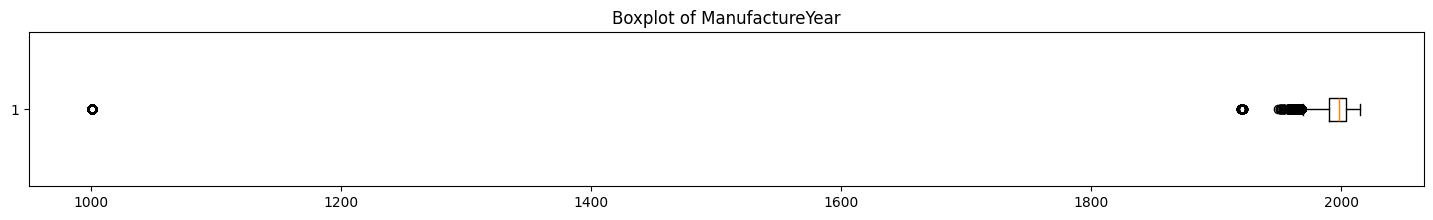

In [38]:
plt.figure(figsize=(18,2))

plt.boxplot(manufacture, vert=False)

plt.title("Boxplot of ManufactureYear")

plt.show()

plt.close()

### Manufacture Year Anomaly
 When analyzing the `ManufactureYear` feature column a strange anomaly was found. 
 
 The most frequently occurring (mode) ManufactureYear in the dataset, indicates a default placeholder value used by the data entry system

In [39]:
print("Mode:", manufacture.mode().iloc[0])

Mode: 1001


The **most frequently occurring** value in the `ManufactureYear` column is **1001**?
This almost certainly seems like a placeholder/default value inserted by some data entry system whenever the actual year was unknown.

In [40]:
manufacture.value_counts().sort_index().head(20)

ManufactureYear
1001    14719
1920       13
1921        7
1949        1
1951        2
1952        3
1953        3
1954        2
1955        1
1957        8
1958        4
1959       13
1960        2
1961       54
1962       41
1963       60
1964       79
1965      142
1966      179
1967      297
Name: count, dtype: int64

In [41]:
manufacture.describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99])

count    138701.000000
mean       1891.640853
std         306.992001
min        1001.000000
1%         1001.000000
5%         1001.000000
25%        1990.000000
50%        1998.000000
75%        2004.000000
95%        2007.000000
99%        2008.000000
max        2015.000000
Name: ManufactureYear, dtype: float64

### Observations

- The feature is heavily concentrated between approximately 1990 and 2015.
- The value 1001 appears 14,719 times (about 10.6% of the dataset) and is unlikely to represent a valid manufacture year.
- The histogram and boxplot both reveal a distinct cluster of anomalous values at 1001, suggesting the use of a placeholder or erroneous code rather than genuine manufacturing dates.
- The mean (1891.64) is substantially lower than the median (1998), indicating that these anomalous values strongly influence the average.
- The feature exhibits strong negative skewness (-2.55) and high kurtosis (4.53), primarily due to the concentration of anomalous low values.
- The unusually large standard deviation (306.99 years) is also driven by the presence of these invalid values.
- This feature will require careful preprocessing before feature engineering. The anomalous `1001` values will be investigated and handled before deriving features such as `AssetAge`.
- The true earliest `ManufactureYear` value is 1920 with 13 machines manufactured that year.

These observations motivated replacing the anomalous placeholder years with missing values before deriving the AssetAge feature in feature engineering section.

### OperationalHoursMeter

OperationalHoursMeter records the total lifetime operating hours of a machine.

This feature is expected to be one of the strongest predictors of selling price, since machines with higher operating hours are generally more heavily used and may experience greater depreciation.

The objectives of this analysis are:

- understand the statistical properties of the feature,
- examine its distribution,
- investigate the extent of missing values,
- identify potential outliers,
- determine whether transformations or imputation strategies may be required during preprocessing.

In [42]:
hours = train_df["OperationalHoursMeter"]

print("Count      :", hours.count())
print("Missing    :", hours.isna().sum())
print("Mean       :", hours.mean())
print("Median     :", hours.median())
print("Mode       :", hours.mode().iloc[0])
print("Std        :", hours.std())
print("Minimum    :", hours.min())
print("Maximum    :", hours.max())
print("Skewness   :", hours.skew())
print("Kurtosis   :", hours.kurt())

Count      : 82058
Missing    : 56643
Mean       : 4553.718942699066
Median     : 1620.0
Mode       : 0.0
Std        : 27922.044849863112
Minimum    : 0.0
Maximum    : 1729600.0
Skewness   : 33.28224827296118
Kurtosis   : 1434.4961430344442


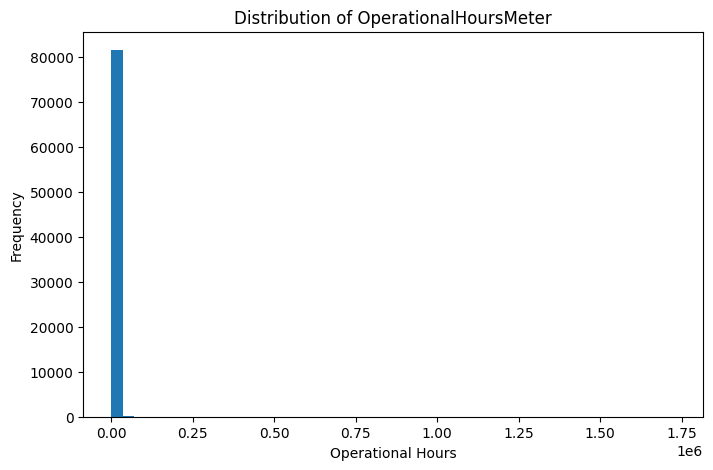

In [43]:
plt.figure(figsize=(8,5))

plt.hist(hours.dropna(), bins=50) #matplotlib cannot plot NaN values

plt.title("Distribution of OperationalHoursMeter")
plt.xlabel("Operational Hours")
plt.ylabel("Frequency")

plt.show()

plt.close()

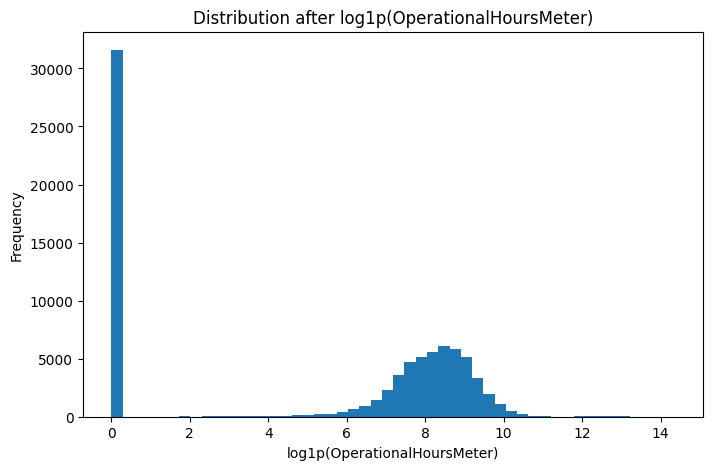

In [44]:
plt.figure(figsize=(8,5))

plt.hist(np.log1p(hours.dropna()), bins=50)

plt.title("Distribution after log1p(OperationalHoursMeter)")
plt.xlabel("log1p(OperationalHoursMeter)")
plt.ylabel("Frequency")

plt.show()

plt.close()

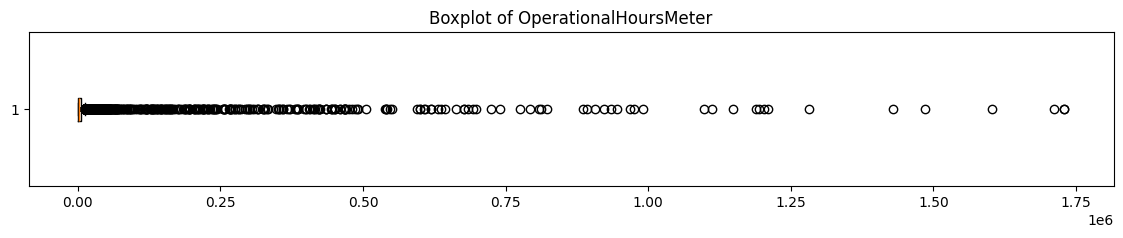

In [45]:
plt.figure(figsize=(14,2))

plt.boxplot(hours.dropna(), vert=False)

plt.title("Boxplot of OperationalHoursMeter")

plt.show()

In [46]:
hours.describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99])

count    8.205800e+04
mean     4.553719e+03
std      2.792204e+04
min      0.000000e+00
1%       0.000000e+00
5%       0.000000e+00
25%      0.000000e+00
50%      1.620000e+03
75%      5.001000e+03
95%      1.303100e+04
99%      2.579601e+04
max      1.729600e+06
Name: OperationalHoursMeter, dtype: float64

In [47]:
missing_pct = hours.isna().mean() * 100

print(f"Missing Percentage: {missing_pct:.2f}%")

Missing Percentage: 40.84%


### Observations

- `OperationalHoursMeter` contains **82,058** non-null values and **56,643** missing values (**40.84% missing**).

- The feature ranges from **0** to **1,729,600** operating hours.

- The distribution is extremely right-skewed, with:
    - Mean = **4,553.72**
    - Median = **1,620**
    - Skewness = **33.28**
    - Kurtosis = **1434.50**

- A large proportion of machines have **0 recorded operating hours**, creating a strong spike at zero.

- Several observations contain extremely large operating hours, producing a long right tail and numerous outliers.

- Applying a **log1p transformation** substantially compresses the distribution, making the non-zero observations easier to interpret.

### Initial Conclusion

`OperationalHoursMeter` appears to be one of the most informative numerical features despite its high missing rate.

The missing values may themselves contain predictive information rather than representing purely random missing data. For example, older machines or equipment without hour-meter tracking systems may naturally have missing operational hour records. 

This hypothesis will be investigated further during exploratory data analysis before deciding on the final preprocessing strategy.

The feature will therefore be retained, and missing values, zero values and extreme observations will be handled during feature engineering and preprocessing rather than being removed during EDA.

The skewness, large number of missing values and wide operating-hour range motivated the creation of engineered features describing operating hours rather than relying solely on the original variable.

## Bivariate Numerical Feature Analysis

Univariate analysis helps us understand the distribution of each feature individually.

The next step is to investigate how the numerical features relate to the target variable (`TargetValue`).

This analysis helps determine:

- whether a feature is positively or negatively associated with selling price,
- whether the relationship appears linear or non-linear,
- whether transformations may improve modelling,
- and whether the feature is likely to contribute useful predictive information.

### ManufactureYear vs TargetValue

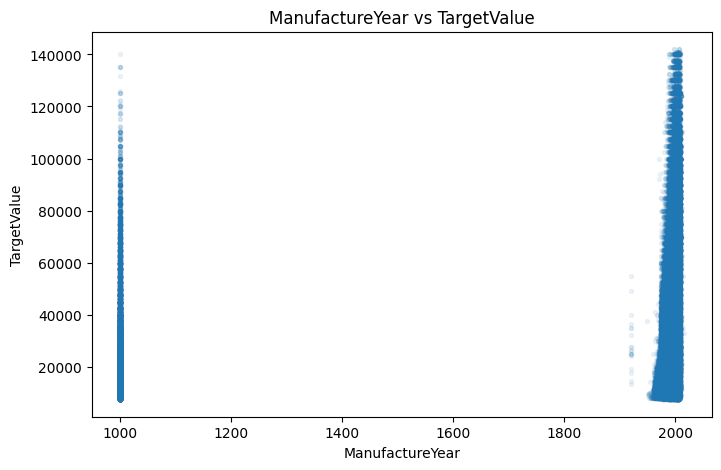

In [48]:
#scatter plot

plt.figure(figsize=(8,5))

plt.scatter(
    train_df["ManufactureYear"],
    train_df["TargetValue"],
    alpha=0.08,
    s=8
)

plt.title("ManufactureYear vs TargetValue")
plt.xlabel("ManufactureYear")
plt.ylabel("TargetValue")

plt.show()
plt.close()

In [49]:
#pearson correlation

temp = train_df[["ManufactureYear", "TargetValue"]].dropna()

temp[["ManufactureYear","TargetValue"]].corr(method="pearson")

,ManufactureYear,TargetValue
ManufactureYear,1.000000,0.204439
TargetValue,0.204439,1.000000


In [50]:
#spearman correlation
corr, p_value = spearmanr(
    temp["ManufactureYear"],
    temp["TargetValue"]
)

print(f"Spearman Correlation : {corr:.4f}")
print(f"P-value : {p_value:.4e}")

Spearman Correlation : 0.3219
P-value : 0.0000e+00


### Observations

- Both Pearson (0.2044) and Spearman (0.3219) correlations indicate a positive relationship between ManufactureYear and TargetValue.

- The Spearman correlation is higher than the Pearson correlation, suggesting that the relationship is monotonic but not strictly linear.

- In general, newer machines tend to have higher selling prices, although considerable variability exists within each manufacture year.

- The scatter plot also highlights the anomalous ManufactureYear value of 1001 observed during the univariate analysis.

### Conclusion

ManufactureYear is an informative predictor of selling price and will be retained for feature engineering. 

Engineered features such as AssetAge will be explored later.

### OperationalHoursMeter vs TargetValue

To understand whether machine usage influences selling price, we compare OperationalHoursMeter with the target variable.

This analysis includes:
- Scatter plot
- Pearson correlation
- Spearman correlation
- Interpretation

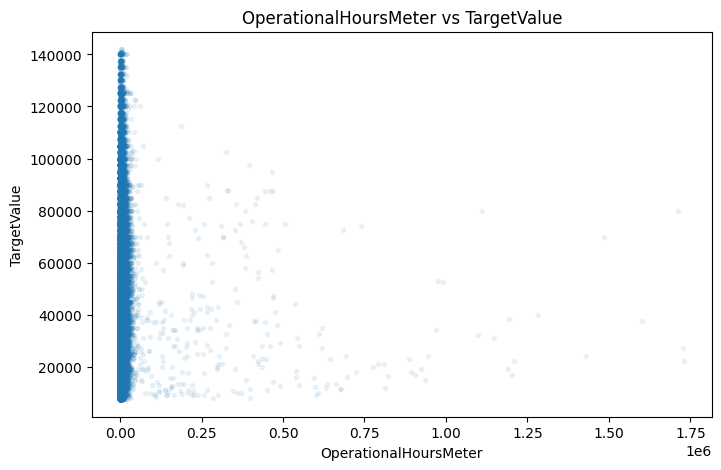

In [51]:
#scatter plot

plt.figure(figsize=(8,5))

plt.scatter(
    train_df["OperationalHoursMeter"],
    train_df["TargetValue"],
    alpha=0.08,
    s=8
)

plt.title("OperationalHoursMeter vs TargetValue")
plt.xlabel("OperationalHoursMeter")
plt.ylabel("TargetValue")

plt.show()
plt.close()

In [52]:
#pearson correlation

temp = train_df[["OperationalHoursMeter", "TargetValue"]].dropna()

temp[["OperationalHoursMeter","TargetValue"]].corr(method="pearson")


,OperationalHoursMeter,TargetValue
OperationalHoursMeter,1.000000,0.001994
TargetValue,0.001994,1.000000


In [53]:
#spearman correlation
corr, p_value = spearmanr(
    temp["OperationalHoursMeter"],
    temp["TargetValue"]
)

print(f"Spearman Correlation : {corr:.4f}")
print(f"P-value : {p_value:.4e}")

Spearman Correlation : 0.0423
P-value : 9.4776e-34


### Observations

- OperationalHoursMeter exhibits an almost negligible linear relationship with TargetValue (Pearson correlation = 0.002).
- The Spearman correlation (0.042) is also very weak, indicating little overall monotonic relationship between operating hours and selling price.
- Although both correlations are statistically significant because of the large sample size, their magnitudes are extremely small and therefore have limited practical significance on their own.
- The scatter plot suggests that the relationship between operating hours and selling price is likely to be complex and non-linear rather than following a simple increasing or decreasing trend.
- OperationalHoursMeter remains an important feature engineering candidate because tree-based models can learn threshold effects and interactions with other variables such as ManufactureYear, machine configuration and equipment type.
- Approximately 40.84% of the values are missing. These missing values may themselves contain useful information, as older or lower-end machines may not record operating hours, making missingness a potentially informative feature rather than random noise.

The numerical analysis identified important relationships between equipment age, operational usage and selling price. These findings led to the creation of age-based, operating-hour and missing-value indicator features used in the feature engineering section.

## Categorical Feature Analysis

Most of the features in this dataset are categorical engineering specifications describing the machine, its configuration and business context.

The objective of this section is to identify which categorical variables exhibit meaningful differences in the target variable.

For each selected feature we will examine:

- frequency distribution
- average selling price by category
- possible rare categories
- observations useful for preprocessing and feature engineering

The analysis focuses on the most informative categorical features rather than every categorical column individually.

In [54]:
important_cat = [
    "UtilizationTier",
    "CabinType",
    "RegionCode",
    "InventoryGroupCategory",
    "VendorPartnerID",
    "AssetScaleFactor",
    "DataOriginCode"
]

In [55]:
def analyse_categorical(feature):

    print(feature)
    print("-" * 60)

    print("\nFrequency:")
    display(train_df[feature].value_counts(dropna=False).head(15))

    # Percentage distribution
    print("\nPercentage distribution:")
    display(
        (train_df[feature].value_counts(dropna=False, normalize=True)*100).round(2).head(20))

    # Mean target value
    print("\nMean target value:")
    display(
        train_df.groupby(feature)["TargetValue"].mean().sort_values(ascending=False).head(20))

    # feature vs average target value plot
    print(f"\n{feature} vs average target value plot:")
    plt.figure(figsize=(8,4))

    train_df.groupby(feature)["TargetValue"]\
        .mean().head(20)\
        .sort_values(ascending=False)\
        .plot(kind="bar")

    plt.ylabel("Average TargetValue")
    plt.title(feature)

    plt.tight_layout()
    plt.show()
    plt.close()

UtilizationTier
------------------------------------------------------------

Frequency:


UtilizationTier
NaN       88226
Medium    24588
Low       17005
High       8882
Name: count, dtype: int64


Percentage distribution:


UtilizationTier
NaN       63.61
Medium    17.73
Low       12.26
High       6.40
Name: proportion, dtype: float64


Mean target value:


UtilizationTier
High      52070.297793
Medium    43698.896738
Low       31866.454219
Name: TargetValue, dtype: float64


UtilizationTier vs average target value plot:


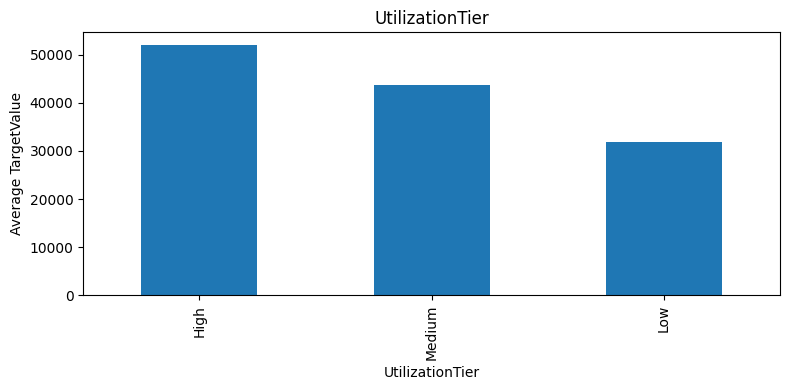

In [56]:
analyse_categorical("UtilizationTier")

### Observations

- `UtilizationTier` contains three ordered categories (`Low`, `Medium`, and `High`) along with a large proportion of missing values (63.61%).

- Among the available observations, the average selling price increases consistently with utilization level:
  - Low: \$31,866
  - Medium: \$43,699
  - High: \$52,070

- This monotonic relationship suggests that the utilization category captures meaningful information about machine value.

- The large proportion of missing values indicates that missingness itself may carry useful information and should be investigated further during feature engineering rather than simply removing the feature.

- Since the categories have a natural order (Low < Medium < High), this feature is an ordinal categorical variable and is a suitable candidate for ordinal encoding during preprocessing.

CabinType
------------------------------------------------------------

Frequency:


CabinType
EROPS         60189
EROPS w AC    55752
OROPS         22760
Name: count, dtype: int64


Percentage distribution:


CabinType
EROPS         43.39
EROPS w AC    40.20
OROPS         16.41
Name: proportion, dtype: float64


Mean target value:


CabinType
EROPS w AC    55663.790788
EROPS         32042.698167
OROPS         31948.147109
Name: TargetValue, dtype: float64


CabinType vs average target value plot:


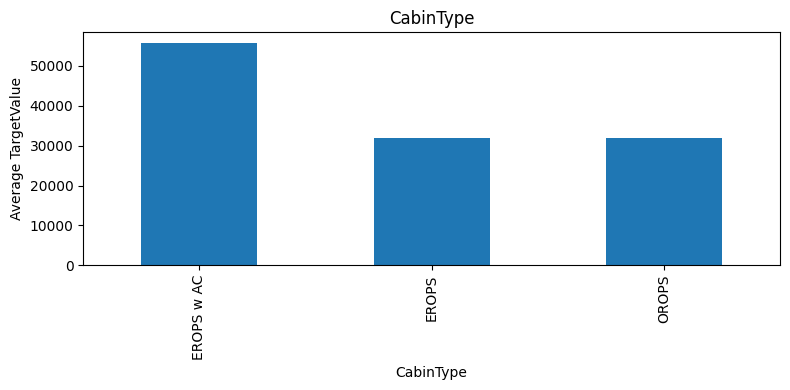

In [57]:
analyse_categorical("CabinType")

### Observations

- `CabinType` contains three categories with no missing values, making it a complete categorical feature for modelling.

- The dataset is dominated by enclosed cabins (`EROPS` and `EROPS w AC`), while `OROPS` represents a smaller proportion of the observations.

- Machines equipped with **EROPS w AC** have a substantially higher average selling price (around \$55,664) compared to both **EROPS** (around \$32,043) and **OROPS** (around \$31,948).

- The large difference in average selling price suggests that cabin configuration captures meaningful differences in machine specifications and market value.

- Since `CabinType` is a nominal categorical feature with only three categories, it will be retained for modelling and encoded appropriately during pre-processing.

RegionCode
------------------------------------------------------------

Frequency:


RegionCode
Florida           23460
Texas             18284
California         9525
Washington         6063
Georgia            5240
North Carolina     4391
Maryland           4352
Mississippi        4227
Colorado           3989
Illinois           3855
Alabama            3723
Tennessee          3602
Ohio               3528
South Carolina     3386
New Jersey         3370
Name: count, dtype: int64


Percentage distribution:


RegionCode
Florida           16.91
Texas             13.18
California         6.87
Washington         4.37
Georgia            3.78
North Carolina     3.17
Maryland           3.14
Mississippi        3.05
Colorado           2.88
Illinois           2.78
Alabama            2.68
Tennessee          2.60
Ohio               2.54
South Carolina     2.44
New Jersey         2.43
Arizona            2.24
Connecticut        2.06
Nevada             1.97
Missouri           1.82
Pennsylvania       1.73
Name: proportion, dtype: float64


Mean target value:


RegionCode
South Dakota     54628.455285
Rhode Island     52992.857143
Unspecified      51705.631399
Nevada           47533.589744
Alabama          47471.214343
North Dakota     46017.015707
West Virginia    45270.577933
Florida          45007.542626
Mississippi      44990.111190
Georgia          44501.412214
Texas            44341.440713
Arizona          43524.403611
Nebraska         43438.772846
New Mexico       43424.448529
Colorado         43261.847581
Montana          42987.826962
Oklahoma         41764.013841
Iowa             41507.443366
Kentucky         41375.221239
Utah             41220.520422
Name: TargetValue, dtype: float64


RegionCode vs average target value plot:


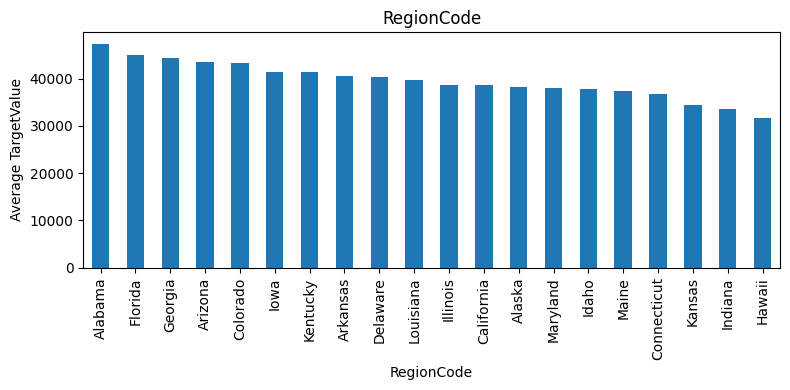

In [58]:
analyse_categorical("RegionCode")

In [59]:
region_summary = (
    train_df
    .groupby("RegionCode")
    .agg(
        Count=("TargetValue", "size"),
        Mean_TargetValue=("TargetValue", "mean")
    )
    .sort_values("Mean_TargetValue", ascending=False)
)

region_summary.head(20)

,Count,Mean_TargetValue
RegionCode,,
South Dakota,123,54628.455285
Rhode Island,14,52992.857143
Unspecified,586,51705.631399
Nevada,2730,47533.589744
Alabama,3723,47471.214343
North Dakota,191,46017.015707
West Virginia,571,45270.577933
Florida,23460,45007.542626
Mississippi,4227,44990.111190


### Observations

- `RegionCode` contains **53 geographical categories**, making it a moderately high-cardinality categorical feature.

- Machinery transactions are concentrated in a few regions, with **Florida (23,460 transactions)** and **Texas (18,284 transactions)** accounting for the largest share of the dataset.

- The average selling price varies across regions, suggesting that regional market conditions may influence machinery price.

- Regions such as **South Dakota** and **Rhode Island** exhibit the highest average selling prices. However, these regions contain relatively few observations (123 and 14 respectively), so their average selling price should be interpreted cautiously.

- In contrast, large-volume regions such as **Florida**, **Texas**, **Georgia**, and **Mississippi** also exhibit relatively high average selling prices, providing stronger evidence that regional differences may contain useful predictive information.

- Overall, the observed regional variation suggests that `RegionCode` is a valuable predictor and will be retained for modelling.

InventoryGroupCategory
------------------------------------------------------------

Frequency:


InventoryGroupCategory
TEX    71018
MG     23405
WL     18872
TTT    14959
BL     10381
SSL       66
Name: count, dtype: int64


Percentage distribution:


InventoryGroupCategory
TEX    51.20
MG     16.87
WL     13.61
TTT    10.79
BL      7.48
SSL     0.05
Name: proportion, dtype: float64


Mean target value:


InventoryGroupCategory
TTT    48733.741239
MG     47722.283828
WL     46468.955331
TEX    39281.266299
BL     23649.794721
SSL    15602.272727
Name: TargetValue, dtype: float64


InventoryGroupCategory vs average target value plot:


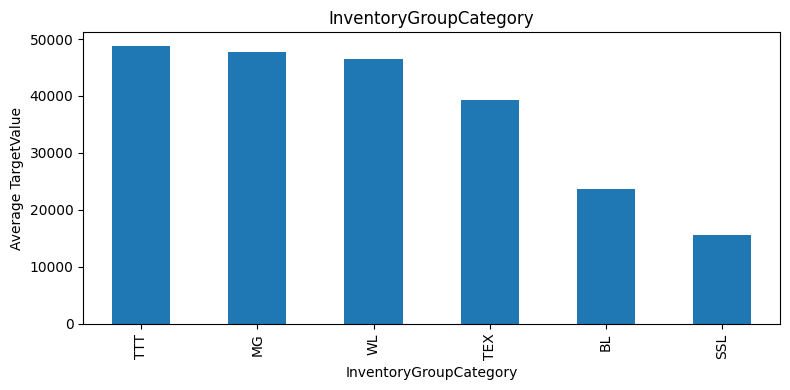

In [60]:
analyse_categorical("InventoryGroupCategory")

### Observations

- `InventoryGroupCategory` contains six categories with no missing values, making it a complete nominal categorical feature.

- More than half of the transactions belong to the **TEX** category (51.20%), followed by **MG** (16.87%) and **WL** (13.61%), indicating that the dataset is concentrated within a few inventory groups.

- The average selling price varies considerably across inventory groups, suggesting that the inventory category captures meaningful differences between equipment types.

- Although **SSL** has the lowest average selling price, it represents only **66 observations (0.05%)** and should therefore be interpreted cautiously due to the small sample size.

- The substantial variation in average selling prices across the major inventory groups indicates that `InventoryGroupCategory` contains useful predictive information and will be retained for modelling.

VendorPartnerID
------------------------------------------------------------

Frequency:


VendorPartnerID
UJF               67828
GTX               18231
MPF               15187
UNKNOWN_VENDOR     6549
HCL                5753
MNT                3786
SLT                2667
DLC                2570
MNJ                2466
SND                2461
RZI                1597
QUG                1181
LQO                1127
VJC                 995
EVS                 918
Name: count, dtype: int64


Percentage distribution:


VendorPartnerID
UJF               48.90
GTX               13.14
MPF               10.95
UNKNOWN_VENDOR     4.72
HCL                4.15
MNT                2.73
SLT                1.92
DLC                1.85
MNJ                1.78
SND                1.77
RZI                1.15
QUG                0.85
LQO                0.81
VJC                0.72
EVS                0.66
SQU                0.45
HJW                0.40
MBO                0.35
NTE                0.34
GMU                0.33
Name: proportion, dtype: float64


Mean target value:


VendorPartnerID
HJW               58256.793478
SLT               49167.259468
DLC               48760.875486
EVS               48031.427015
RKC               46152.657005
MHV               45727.380952
SND               43734.711499
AFZ               43724.663677
RGK               43441.081081
UJF               43037.664018
RZI               40396.994364
GTX               40246.206132
HCL               40148.559360
CBS               40129.937304
TAI               39790.217391
MPF               39576.665898
UNKNOWN_VENDOR    39043.670789
SGU               38484.649123
MNJ               37539.324818
MNT               36700.521183
Name: TargetValue, dtype: float64


VendorPartnerID vs average target value plot:


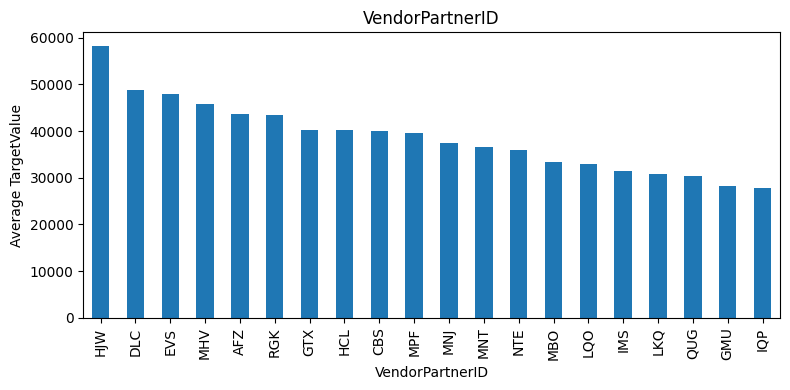

In [61]:
analyse_categorical("VendorPartnerID")

In [62]:
vendor_summary = (
    train_df
    .groupby("VendorPartnerID")
    .agg(
        Count=("TargetValue", "size"),
        Mean_TargetValue=("TargetValue", "mean")
    )
    .sort_values("Mean_TargetValue", ascending=False)
)

vendor_summary.head(20)

,Count,Mean_TargetValue
VendorPartnerID,,
HJW,552,58256.793478
SLT,2667,49167.259468
DLC,2570,48760.875486
EVS,918,48031.427015
RKC,207,46152.657005
MHV,378,45727.380952
SND,2461,43734.711499
AFZ,223,43724.663677
RGK,185,43441.081081


### Observations

- `VendorPartnerID` contains **31 vendor categories**, making it a moderately high-cardinality categorical feature.

- Nearly half of all machinery transactions (**48.90%**) originate from a single vendor (`UJF`), indicating that the vendor distribution is highly concentrated.

- Average selling prices vary across vendors, suggesting that vendor-specific factors may contribute useful predictive information.

- Although **HJW** exhibits the highest average selling price (~\$58,257), it contains only **552 observations**. Similarly, several other vendors with high average prices represent relatively small sample sizes. These averages should therefore be interpreted cautiously.

- In contrast, major vendors such as **UJF (67,828 observations)**, **GTX (18,231 observations)**, **MPF (15,187 observations)** and **HCL (5,753 observations)** contain sufficiently large sample sizes to provide more reliable estimates of their average selling prices.

- The `UNKNOWN_VENDOR` category accounts for **6,549 observations (4.72%)** and exhibits an average selling price comparable to several known vendors. Therefore, it will be treated as a valid categorical level rather than as a missing value.

- Overall, the variation in average selling prices across vendors suggests that `VendorPartnerID` contains useful predictive information and will be retained for modelling.

AssetScaleFactor
------------------------------------------------------------

Frequency:


AssetScaleFactor
NaN               41210
Large / Medium    39222
Medium            21918
Small             18119
Mini              13663
Large              2775
Compact            1794
Name: count, dtype: int64


Percentage distribution:


AssetScaleFactor
NaN               29.71
Large / Medium    28.28
Medium            15.80
Small             13.06
Mini               9.85
Large              2.00
Compact            1.29
Name: proportion, dtype: float64


Mean target value:


AssetScaleFactor
Medium            53305.595857
Large             53209.278631
Large / Medium    49910.742695
Small             33909.204481
Compact           16517.530658
Mini              15912.086950
Name: TargetValue, dtype: float64


AssetScaleFactor vs average target value plot:


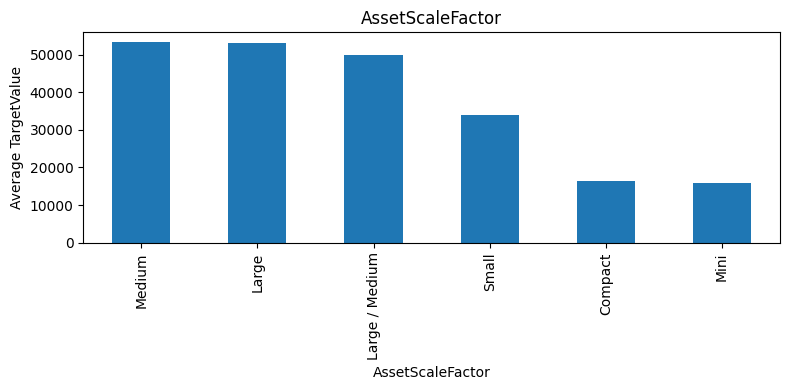

In [63]:
analyse_categorical("AssetScaleFactor")

### Observations

- `AssetScaleFactor` contains six size categories along with **29.71% missing values**, indicating that the feature will require an appropriate missing-value strategy during preprocessing.

- Larger machines (`Medium`, `Large`, and `Large / Medium`) exhibit substantially higher average selling prices (approximately \$50,000–\$53,000) compared to `Small`, `Compact`, and `Mini` machines.

- The clear decreasing trend in average selling price with decreasing machine size suggests that `AssetScaleFactor` captures important information related to machine capacity and market value.

- Despite the missing values, the feature demonstrates strong predictive potential and will be retained for modelling.

DataOriginCode
------------------------------------------------------------

Frequency:


DataOriginCode
ADI149    59541
CEA153    36009
ACH138    16909
FFA166    13423
IHB189    12818
ZIA190        1
Name: count, dtype: int64


Percentage distribution:


DataOriginCode
ADI149    42.93
CEA153    25.96
ACH138    12.19
FFA166     9.68
IHB189     9.24
ZIA190     0.00
Name: proportion, dtype: float64


Mean target value:


DataOriginCode
ZIA190    46173.200000
FFA166    43669.995530
CEA153    43173.976700
ADI149    41403.405939
ACH138    40105.018570
IHB189    37050.183336
Name: TargetValue, dtype: float64


DataOriginCode vs average target value plot:


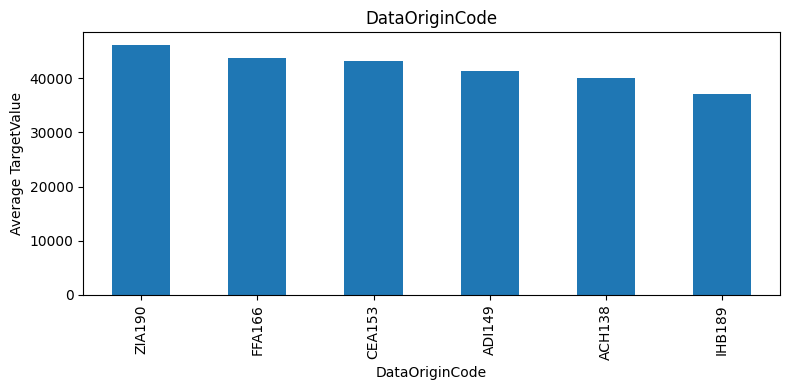

In [64]:
analyse_categorical("DataOriginCode")

### Observations

- `DataOriginCode` contains six categories and has **no missing values**, making it a complete categorical feature.

- The majority of the observations originate from three data sources (`ADI149`, `CEA153`, and `ACH138`), while `ZIA190` contains only a single observation.

- The average selling price varies across the major data sources, suggesting that the origin of the data may capture differences in business processes or machine populations.

- Since `ZIA190` contains only one observation, its average selling price should not be interpreted as representative.

- Overall, the variation across the major data sources suggests that `DataOriginCode` may contain useful predictive information and will be retained for modelling.

### Summary of Categorical Feature Analysis

The selected categorical features exhibit meaningful variation in average selling prices across their categories, indicating that they contain useful predictive information for the regression task.

The analysis also analysed two moderately high-cardinality features (`RegionCode` and `VendorPartnerID`), whose category-wise averages were interpreted together with their sample sizes to avoid drawing conclusions from very small groups.

Several categorical features contain missing values (such as `UtilizationTier` and `AssetScaleFactor`), suggesting that appropriate imputation strategies will be required during preprocessing.

Overall, the categorical EDA supports retaining these features for further feature engineering and model development.

## High-Cardinality Feature Assessment

In [65]:
categorical_cols = train_df.select_dtypes(include="object").columns

high_cardinality = pd.DataFrame({
    "Unique Categories": train_df[categorical_cols].nunique()
})

high_cardinality = high_cardinality.sort_values(
    "Unique Categories",
    ascending=False
)

high_cardinality.head(10)

,Unique Categories
TransactionDate,3676
Spec_FullDescriptor,3505
Spec_BaseClass,1249
Spec_SubClass,147
Spec_VariantModifier,132
Spec_ReleaseSeries,113
FunctionalClassification,65
RegionCode,53
VendorPartnerID,31
col22,27


### Observations

- Several categorical features exhibit high cardinality, particularly `ProductConfigID`, `Spec_FullDescriptor`, and `Spec_BaseClass`, each containing hundreds or thousands of unique categories.

- High-cardinality features often contain valuable predictive information but require careful encoding to prevent excessive dimensionality and overfitting.

- Since tree-based models can effectively utilize high-cardinality categorical variables, these features will be retained for further investigation during pre-processing rather than being removed during EDA.

- The final encoding strategy for these variables will be determined during the feature engineering stage.

## Correlation Summary

The numerical correlation analysis indicates that `ManufactureYear` exhibits a moderate positive relationship with the target variable, suggesting that newer machines generally have higher selling prices. 

`OperationalHoursMeter` exhibits a very weak linear and monotonic relationship with the target variable. However, this does not necessarily imply that the feature lacks predictive value. The variable is highly skewed, contains substantial missing values and may interact with other variables such as machine age and model specifications.

The categorical feature analysis revealed substantial differences in average selling prices across several categories, including `CabinType`, `UtilizationTier`, `InventoryGroupCategory`, `VendorPartnerID`, `RegionCode`, `AssetScaleFactor` and `DataOriginCode`. These observations suggest that both numerical and categorical variables contribute useful predictive information for the regression task.

Overall, the EDA indicates that the dataset contains multiple informative features which will be retained and further engineered in the following sections.

## Identifier Feature Analysis

Several identifier-like variables are present in the dataset. Although identifiers are often removed before modelling, not all identifier features are purely arbitrary.

Therefore, each identifier feature is evaluated individually before deciding whether it should be retained.

In [66]:
identifier_summary = pd.DataFrame({
    "Feature": ["TransactionID","AssetID","ProductConfigID"],
    "Unique Values": [
        train_df["TransactionID"].nunique(),
        train_df["AssetID"].nunique(),
        train_df["ProductConfigID"].nunique()
    ],
    "Decision": [
        "Drop",
        "Investigate",
        "Keep"
    ]
})

identifier_summary

,Feature,Unique Values,Decision
0,TransactionID,138701,Drop
1,AssetID,120111,Investigate
2,ProductConfigID,3594,Keep


### Observations

- `TransactionID` is a unique identifier assigned to each transaction and contains no predictive information. It will be removed before modelling.

- `AssetID` identifies individual machines. Since many machines appear multiple times in the dataset, this feature may capture historical information and will be investigated further during feature engineering.

- `ProductConfigID` represents recurring machine configurations rather than unique transactions. The repeated occurrence of configuration IDs suggests that the feature may contain valuable predictive information and will therefore be retained for modelling.

## Key Insights from Exploratory Data Analysis
The exploratory data analysis provided a detailed understanding of the dataset structure, feature characteristics and target variable behaviour.

Key findings include:

- Several numerical and categorical variables exhibit meaningful relationships with the target variable.
- High-cardinality technical specification features were identified and will require appropriate encoding during preprocessing.
- Missing values are concentrated in specific engineering specification features, while some missingness itself may contain predictive information.
- The target variable is positively skewed, motivating the use of a logarithmic transformation during modelling.
- Machine age, technical specifications, operational characteristics and categorical configuration features all appear to contain useful predictive information.

Based on these observations, the dataset is ready for further processing in the following sections.

Transition to Feature Engineering

The exploratory data analysis identified several variables with meaningful predictive potential, along with data quality issues that require preprocessing before modelling.

# Evaluation Metric

An evaluation metric is required to objectively measure model performance and compare different regression models during development. 

Since the Kaggle competition evaluates submissions using **Root Mean Squared Logarithmic Error (RMSLE)**, the same metric will be used throughout model development and validation to ensure consistency between local evaluation and leaderboard performance.

The Root Mean Squared Logarithmic Error (RMSLE) is defined as:

$$ \text{RMSLE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}\left(\log(1+\hat y_i) - \log(1+y_i)\right)^2} $$

### Why RMSLE?

RMSLE is the official evaluation metric used in the competition and therefore serves as the primary metric for model comparison during development.

Since RMSLE evaluates prediction errors on the logarithmic scale, it focuses on relative prediction error rather than absolute monetary differences. This makes it well suited for target variables that exhibit positive skewness and contain high-value observations.

As observed during the exploratory data analysis, `TargetValue` has a positively skewed distribution. Applying a logarithmic transformation reduces this skewness and aligns naturally with the competition's evaluation metric.

# Train-Validation Split

The exploratory data analysis is now complete. Based on the insights obtained during EDA, the dataset is split into training and validation sets before feature engineering and pre-processing.

The validation set is held out throughout model development to provide an unbiased estimate of model performance.

In [67]:
target = "TargetValue"

X = train_df.drop(columns=[target])
y = train_df[target]

#log-transform the target values
y_log = np.log1p(y)

In [68]:
#Train-validation Split
X_train,X_valid,y_train,y_valid = train_test_split(X,y_log,test_size = 0.2,random_state = 42)

print("Training set: ", X_train.shape)

print("Validation set: ", X_valid.shape)

Training set:  (110960, 49)
Validation set:  (27741, 49)


# Feature Engineering

Feature engineering transforms the raw dataset into a richer representation by creating new variables based on dataset knowledge and insights obtained during exploratory data analysis.

The engineered features are designed to capture machine age, temporal information, equipment utilization and missing-value patterns that may improve predictive performance.

Only features that are justified through the EDA or machine learning best practices are engineered. 

All feature engineering is performed after the train-validation split to prevent data leakage.

## Date Features

- TransacationYear
- TransactionMonth

In [69]:
def add_date_features(df):

    df = df.copy()

    #convert TransactionDate feature to a datetime data type
    df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

    #extract new features from TransactionDate: 
    
    # TransactionYear and TransactionMonth 
    
    df["TransactionYear"] = df["TransactionDate"].dt.year
    df["TransactionMonth"] = df["TransactionDate"].dt.month

    return df

## Descriptor Length

In [70]:
def add_descriptor_length(df):

    df = df.copy()

    df["DescriptorLength"] = (
        df["Spec_FullDescriptor"]
        .fillna("")
        .str.len()
    )

    return df

## Missing value indicator features

- HasOperationalHours
- HasvariantModifiers
- HasReleaseSeries

In [71]:
def add_missing_indicators(df):

    df = df.copy()

    df["HasOperationalHours"] = (
        df["OperationalHoursMeter"].notna().astype(int)
    )

    df["HasVariantModifier"] = (
        df["Spec_VariantModifier"].notna().astype(int)
    )

    # df["HasReleaseSeries"] = (
    #     df["Spec_ReleaseSeries"].notna().astype(int)
    # )

    return df

## Missing Feature Count

In [72]:
def add_missing_count(df):

    df = df.copy()

    # missing information can be an indicator of cheaper or older machines with less specs or less technology to document specs, 
    # all missing values as a sum count might be of some predictive importance of selling price of a machine.
    
    df["MissingFeatureCount"] = df.isna().sum(axis=1)

    return df

## Asset Age

In [73]:
def add_asset_age(df):

    df = df.copy()
    

    # Replace invalid manufacture years
    df["ManufactureYear"] = (
        df["ManufactureYear"]
        .replace([1000, 1001], np.nan)
    )
    
    # Asset age is a measure of price depreciation over time of a machine before it is sold.

    df["AssetAge"] = (
        df["TransactionYear"]
        - df["ManufactureYear"]
    )

    # Negative ages are not logically meaningful.
    # Treat them as newly manufactured assets.
    
    df["AssetAge"] = (
        df["AssetAge"]
        .clip(lower=0)
    )

    return df


## Age Bucket

In [74]:
def add_age_bucket(df):

    df = df.copy()

    df["AgeBucket"] = (
        pd.cut(
            df["AssetAge"],
            bins=[-5, 2, 5, 10, 20, 40, 100],
            labels=[
                "0-2",
                "3-5",
                "6-10",
                "11-20",
                "21-40",
                "40+"
            ]
        )
        .astype(object)
    )

    return df

## Log Operational Hours

In [75]:
def add_log_operational_hours(df):

    df = df.copy()

    df["LogOperationalHours"] = np.log1p(df["OperationalHoursMeter"])

    return df

## Hours Per Year

In [76]:
def add_hours_per_year(df):

    df = df.copy()

    # if asset age is less than a year division by zero becomes undefined, so we replace zero asset age rows with one.
    age = df["AssetAge"].clip(lower=1)

    df["HoursPerYear"] = (
        df["OperationalHoursMeter"]
        / age
    )

    return df

## Product Config Frequency

In [77]:
# Product Configuration Frequency Map
product_config_frequency = (X_train["ProductConfigID"].value_counts())

def add_product_config_frequency(df):

    df = df.copy()

    df["ProductConfigFrequency"] = (df["ProductConfigID"].map(product_config_frequency).fillna(1))

    return df

## Base Class Frequency

In [78]:
# Base Class Frequency Map
base_class_frequency = (X_train["Spec_BaseClass"].value_counts())

def add_base_class_frequency(df):

    df = df.copy()

    df["BaseClassFrequency"] = (df["Spec_BaseClass"].map(base_class_frequency).fillna(1))

    return df

## Sub Class Frequency

In [79]:
subclass_frequency_map = (train_df["Spec_SubClass"].value_counts())

def add_subclass_frequency(df, frequency_map):

    df = df.copy()

    df["SubClassFrequency"] = (df["Spec_SubClass"].map(frequency_map).fillna(0))

    return df

## Variant Frequency

In [80]:
variant_frequency_map = (X_train["Spec_VariantModifier"].value_counts())

def add_variant_frequency(df):

    df = df.copy()

    df["VariantFrequency"] = (df["Spec_VariantModifier"].map(variant_frequency_map).fillna(0))

    return df

## Asset Frequency

In [81]:
asset_frequency_map = (X_train["AssetID"].value_counts())

def add_asset_frequency(df):

    df = df.copy()

    df["AssetFrequency"] = (df["AssetID"].map(asset_frequency_map).fillna(1))

    return df

## Premium Cabin

In [82]:
def add_cabin_premium(df):

    df = df.copy()

    premium = ["EROPS w AC"]

    df["PremiumCabin"] = (df["CabinType"].isin(premium).astype(int))

    return df

## Descriptor Word Count

In [83]:
def add_descriptor_word_count(df):

    df = df.copy()

    df["DescriptorWordCount"] = (df["Spec_FullDescriptor"].fillna("").str.split().str.len())

    return df

## Missing Features Ratio

In [84]:
def add_missing_ratio(df):

    df = df.copy()

    df["MissingFeatureRatio"] = (df.isna().mean(axis=1))

    return df

## Missing Spec Count

In [85]:
spec_columns = [
    "Spec_BaseClass",
    "Spec_SubClass",
    "Spec_ReleaseSeries",
    "Spec_VariantModifier",
    "Spec_FullDescriptor"
]

def add_missing_spec_count(df):

    df = df.copy()

    df["MissingSpecCount"] = (df[spec_columns].isna().sum(axis=1))

    return df

## Descriptor Has Numbers

In [86]:
def add_descriptor_has_numbers(df):

    df = df.copy()

    df["DescriptorHasNumbers"] = (df["Spec_FullDescriptor"].fillna("").str.contains(r"\d").astype(int))

    return df

## Release Series Frequency

In [87]:
# Release Series Frequency Map
release_series_frequency_map = (X_train["Spec_ReleaseSeries"].value_counts())

def add_release_series_frequency(df):

    df = df.copy()

    df["ReleaseSeriesFrequency"] = (df["Spec_ReleaseSeries"].map(release_series_frequency_map).fillna(0))

    return df

Feature engineering was guided by exploratory data analysis (EDA), domain knowledge of heavy equipment depreciation, equipment utilization, specification completeness, and category frequency.

Candidate features that did not improve validation performance were commented out and excluded from the final pipeline. They are retained only for reference and comparison.

In [88]:
def engineer_features(df):

    df = add_date_features(df)

    # df = add_log_operational_hours(df)

    df = add_asset_age(df)

    # df = add_age_bucket(df)

    # df = add_expected_hours(df,baseclass_hours_map)
    
    # df = add_hours_deviation(df)

    df = add_hours_per_year(df)

    df = add_descriptor_length(df)

    df = add_missing_indicators(df)

    df = add_missing_count(df)

    df = add_product_config_frequency(df)

    df = add_base_class_frequency(df)
    
    df = add_subclass_frequency(df, subclass_frequency_map)

    # df = add_variant_frequency(df)

    df = add_release_series_frequency(df)

    df = add_asset_frequency(df)

    df = add_cabin_premium(df)

    df = add_descriptor_word_count(df)

    # df = add_descriptor_has_numbers(df)

    # df = add_missing_ratio(df)

    df = add_missing_spec_count(df)

    return df

## Engineer Features

In [89]:
X_train = engineer_features(X_train)
X_valid = engineer_features(X_valid)

### Product Config ID Statistics

In [90]:
# ---------------------------------------------------
# ProductConfigID statistics
# ---------------------------------------------------

product_config_year_count_map = (

    X_train
    .groupby("ProductConfigID")["TransactionYear"].nunique()

)

product_config_region_count_map = (

    X_train
    .groupby("ProductConfigID")["RegionCode"].nunique()

)

product_config_year_span_map = (

    X_train
    .groupby("ProductConfigID")["TransactionYear"]
    .agg(lambda x: x.max() - x.min())

)

## ProductConfigYearCount and ProductConfigRegion Count

In [91]:
def add_productconfig_year_count(df):

    df = df.copy()

    df["ProductConfigYearCount"] = (df["ProductConfigID"].map(product_config_year_count_map).fillna(0))

    return df

def add_productconfig_region_count(df):

    df = df.copy()

    df["ProductConfigRegionCount"] = (df["ProductConfigID"].map(product_config_region_count_map).fillna(0))

    return df


In [92]:

def engineer_features2(df):
    
    df = add_productconfig_year_count(df)
    df = add_productconfig_region_count(df)

    return df

In [93]:
X_train = engineer_features2(X_train)
X_valid = engineer_features2(X_valid)

In [94]:
print("Training shape :", X_train.shape)
print("Validation shape:", X_valid.shape)

# X_train.head()

Training shape : (110960, 67)
Validation shape: (27741, 67)


# Feature Engineering Experiments

## Asset ID inspection

Experiment 1: AssetAge Validation

Question

Should negative AssetAge values be retained, clipped to zero, or treated as missing values?

Hypothesis

AssetAge represents the number of years between a machine's manufacture date and its sale. Negative values are not logically possible and are likely caused by data quality issues. Correcting these values may improve data consistency with possibly improving predictive power.

Method

Three preprocessing strategies were evaluated while keeping the remainder of the pipeline unchanged:

Keep negative values unchanged.
Clip negative values to zero.
Replace negative values with NaN and allow the median imputer to estimate them.

In [95]:
#Negative assetage values inspection

asset_age = (
    X_train["TransactionYear"]
    - X_train["ManufactureYear"].replace([1000, 1001], np.nan)  #handling the ManufactureYear Anomaly
)

print("Negative AssetAge values:",
      (asset_age < 0).sum())

print(asset_age.describe())

Negative AssetAge values: 4
count    99201.000000
mean        10.022510
std          7.410923
min         -2.000000
25%          5.000000
50%          8.000000
75%         13.000000
max         92.000000
dtype: float64


Results:

|Strategy|Validation RMSLE|
| --- | --- |
|Keep negative values|0.20080|
|Clip negative values to 0|0.20080|
|Replace with NaN|0.20081|


Decision:

Only four observations contained negative AssetAge values. 

Clipping these values to zero produced identical validation performance to retaining them while removing logically impossible ages. Replacing them with missing values resulted in a marginally worse validation score. Therefore, negative asset ages were clipped to zero to preserve domain consistency without sacrificing predictive performance.

## Missing Feature Value Threshold

Experiment 2: Can features with 80–90% missingness still contain predictive signal?

Question

Should features be removed solely based on a missing value threshold?

Hypothesis

Features with extremely high missing values are less likely to contribute useful predictive information, but some borderline features may still contain signal.

Method

Three thresholds (80%, 85%, and 90%) were investigated. Before changing the threshold, the model was run and the validation score was noted. and then the threshold was increased and less features were removed and the model was trained and validation score was checked again.

In [96]:
candidate_missing_features = missing_summary[
    (missing_summary["Missing (%)"] >= 80) &
    (missing_summary["Missing (%)"] < 90)
]

candidate_missing_features

,Missing Values,Missing (%)
col27,123742,89.21
col28,123742,89.21
col29,119829,86.39
col30,119829,86.39
col13,115296,83.13
col14,115296,83.13
col7,115296,83.13
col6,115296,83.13
col9,115296,83.13
col8,115296,83.13


In [97]:
missing_threshold_80_cols = (
    missing_summary[missing_summary["Missing (%)"] > 80]
    .index
    .tolist()
)

missing_threshold_85_cols = (
    missing_summary[missing_summary["Missing (%)"] > 85]
    .index
    .tolist()
)

missing_threshold_90_cols = (
    missing_summary[missing_summary["Missing (%)"] > 90]
    .index
    .tolist()
)

In [98]:
print("Columns missing value % >80:",missing_threshold_80_cols)

print("Columns missing value % >85:",missing_threshold_85_cols)

print("Columns missing value % >90:",missing_threshold_90_cols)

Columns missing value % >80: ['col19', 'col18', 'col5', 'col4', 'col27', 'col28', 'col29', 'col30', 'col13', 'col14', 'col7', 'col6', 'col9', 'col8', 'col11']
Columns missing value % >85: ['col19', 'col18', 'col5', 'col4', 'col27', 'col28', 'col29', 'col30']
Columns missing value % >90: ['col19', 'col18', 'col5', 'col4']


Results:

|Missing Value Strategy|Validation RMSLE|
| --- | --- |
|Drop >80%|0.20142|
|Drop >85%|0.20096|
|Drop >90%|0.20080|
|Keep all columns|0.20063|


Decision:

Validation performance consistently decreased as the missing-value threshold became more aggressive. Therefore, no features were removed solely on the basis of missing-value percentage. This suggests that even highly sparse specification fields may contain useful predictive information for the model.

Limitation

This experiment evaluates the preprocessing strategy as a whole rather than the contribution of individual features. 
Determining the importance of each feature would require a separate feature-level ablation study.

## High Cardinality Threshold


Experiment 3: How do you define high-cardinality threshold?

Question

What threshold should define a high-cardinality categorical feature vs a low caridnality categorical feature?

Hypothesis

A larger threshold may allow moderately sized categorical features to benefit from one-hot encoding while reserving ordinal encoding for only truly high-cardinality features.

Method

Evaluated thresholds of 50, 100, and 150 unique categories while keeping the remainder of the preprocessing pipeline unchanged.

Results:

|Threshold|Validation RMSLE|
|---|---|
|50|0.20173|
|100|0.20063|
|150|0.20050|

Decision

A threshold of 150 produced the best validation performance. This indicates that several categorical features previously treated as high-cardinality benefited from one-hot encoding rather than ordinal encoding. Consequently, the high-cardinality threshold was increased from 100 to 150 for the preprocessing section.

Although the dimensionality of features approximately doubled, the improvement in validation RMSLE justified the additional computational cost. The increase remained computationally manageable for this dataset.

## Frequency Features

Experiment 4: Engineered Frequency Features

Question

Do frequency-based engineered features improve predictive performance?

Hypothesis

Frequently occurring machine configurations may capture market popularity and common equipment configurations, providing useful information for price prediction.

Experiment

Remove the engineered frequency features from the feature engineering pipeline while keeping all other preprocessing and model settings unchanged.

Results

|Configuration|Validation RMSLE|
| --- | --- |
|With engineered frequency features|0.20050|
|Without engineered frequency features|0.20147|

Decision

The engineered frequency features consistently improved validation performance and were retained in the final model.

# Pre-processing

The engineered dataset still contains missing values, categorical variables, identifier columns and features with different data types. These must be transformed into a format suitable for machine learning algorithms.

The preprocessing pipeline is designed to:

- Remove features that do not contribute meaningful predictive information.
- Handle missing values without introducing data leakage.
- Encode categorical variables into numerical representations.
- Preserve the same preprocessing steps for both the training and validation datasets.

The preprocessing pipeline is fitted only on the training data and subsequently applied to the validation data to ensure unbiased model evaluation.

In [99]:
X_train.dtypes.value_counts()

object            43
int64             15
float64            6
int32              2
datetime64[ns]     1
Name: count, dtype: int64

## Feature Selection

Before preprocessing, features that are not useful for prediction or have already been transformed into more informative representations are removed.

The remaining features are grouped according to their data type and semantic meaning so that appropriate preprocessing techniques can be applied.

In [100]:
# Numerical features
numerical_features = X_train.select_dtypes(include=["number"]).columns.tolist()

# Categorical features
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# Datetime feature
datetime_features = X_train.select_dtypes(include=["datetime"]).columns.tolist()

In [101]:
print("Number of numerical features :", len(numerical_features))
print("Number of categorical features:", len(categorical_features))
print("Number of Datetime features:", len(datetime_features))


print("\nTotal Features Count:",len(numerical_features)+len(categorical_features)+len(datetime_features))

Number of numerical features : 23
Number of categorical features: 43
Number of Datetime features: 1

Total Features Count: 67


In [102]:
print("Numerical Features:\n",numerical_features)

print("\nCategorical Features:\n",categorical_features)

print("\nDatetime Features:\n",datetime_features)

Numerical Features:
 ['TransactionID', 'AssetID', 'ProductConfigID', 'ManufactureYear', 'OperationalHoursMeter', 'TransactionYear', 'TransactionMonth', 'AssetAge', 'HoursPerYear', 'DescriptorLength', 'HasOperationalHours', 'HasVariantModifier', 'MissingFeatureCount', 'ProductConfigFrequency', 'BaseClassFrequency', 'SubClassFrequency', 'ReleaseSeriesFrequency', 'AssetFrequency', 'PremiumCabin', 'DescriptorWordCount', 'MissingSpecCount', 'ProductConfigYearCount', 'ProductConfigRegionCount']

Categorical Features:
 ['DataOriginCode', 'VendorPartnerID', 'UtilizationTier', 'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor', 'FunctionalClassification', 'RegionCode', 'InventoryGroupCategory', 'InventoryGroupDescription', 'col1', 'CabinType', 'Forks', 'col3', 'col4', 'DrivetrainType', 'col5', 'col6', 'col7', 'col8', 'col9', 'col10', 'col11', 'col12', 'col13', 'col14', 'col15', 'col16', 'col18', 'col19', 'col20', 'col21', '

## Feature Classification

Before constructing the preprocessing pipeline, the features are grouped according to their semantic meaning rather than only their pandas data types.

Therefore, the features are further classified into:

- Identifier features
- Numerical features
- Ordinal categorical features
- Nominal categorical features
- Datetime features

This semantic classification determines how each feature will be transformed before model training.

In [103]:
identifier_features = [
    "TransactionID",
    "AssetID",
    "ProductConfigID"
]

print("\nIdentifier Features:\n",identifier_features)


Identifier Features:
 ['TransactionID', 'AssetID', 'ProductConfigID']


In [104]:
ordinal_features = [
    "UtilizationTier"
]

print("\nOrdinal Features:\n",ordinal_features)


Ordinal Features:
 ['UtilizationTier']


In [105]:
nominal_features = []

for feature in categorical_features:

    if feature not in ordinal_features:
        nominal_features.append(feature)

print("\nNominal Features count:\n",len(nominal_features))
print("\nNominal Features:\n",nominal_features)


Nominal Features count:
 42

Nominal Features:
 ['DataOriginCode', 'VendorPartnerID', 'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor', 'FunctionalClassification', 'RegionCode', 'InventoryGroupCategory', 'InventoryGroupDescription', 'col1', 'CabinType', 'Forks', 'col3', 'col4', 'DrivetrainType', 'col5', 'col6', 'col7', 'col8', 'col9', 'col10', 'col11', 'col12', 'col13', 'col14', 'col15', 'col16', 'col18', 'col19', 'col20', 'col21', 'col22', 'col23', 'col24', 'col25', 'col27', 'col28', 'col29', 'col30']


In [106]:
new_numerical_features = []

for feature in numerical_features:

    if feature not in identifier_features:
        new_numerical_features.append(feature)

numerical_features = new_numerical_features

print("\nNumerical Features:\n",numerical_features)


Numerical Features:
 ['ManufactureYear', 'OperationalHoursMeter', 'TransactionYear', 'TransactionMonth', 'AssetAge', 'HoursPerYear', 'DescriptorLength', 'HasOperationalHours', 'HasVariantModifier', 'MissingFeatureCount', 'ProductConfigFrequency', 'BaseClassFrequency', 'SubClassFrequency', 'ReleaseSeriesFrequency', 'AssetFrequency', 'PremiumCabin', 'DescriptorWordCount', 'MissingSpecCount', 'ProductConfigYearCount', 'ProductConfigRegionCount']


In [107]:
print("\nDatetime Features:\n",datetime_features)


Datetime Features:
 ['TransactionDate']


## Categorizing Nominal Features by Cardinality

Nominal categorical features are further divided into low-cardinality and high-cardinality groups based on the number of unique categories.

- Low-cardinality features (≤ 100 unique categories) are one-hot encoded since they generate a manageable number of additional features.
- High-cardinality features (> 100 unique categories) are ordinal encoded for the initial baseline model to avoid a large increase in dimensionality.

This strategy balances model complexity, computational efficiency and predictive performance while preserving potentially informative categorical features.

In [108]:
# Threshold for high-cardinality features
CARDINALITY_THRESHOLD = 150

low_cardinality_features = []
high_cardinality_features = []

for feature in nominal_features:

    unique_values = X_train[feature].nunique()

    if unique_values <= CARDINALITY_THRESHOLD:
        low_cardinality_features.append(feature)

    else:
        high_cardinality_features.append(feature)

In [109]:
print("Low Cardinality :", len(low_cardinality_features))

print("\nLow Cardinality Features:\n",low_cardinality_features)

print("\nHigh Cardinality:", len(high_cardinality_features))

print("\nHigh Cardinality Features:\n",high_cardinality_features)

Low Cardinality : 40

Low Cardinality Features:
 ['DataOriginCode', 'VendorPartnerID', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor', 'FunctionalClassification', 'RegionCode', 'InventoryGroupCategory', 'InventoryGroupDescription', 'col1', 'CabinType', 'Forks', 'col3', 'col4', 'DrivetrainType', 'col5', 'col6', 'col7', 'col8', 'col9', 'col10', 'col11', 'col12', 'col13', 'col14', 'col15', 'col16', 'col18', 'col19', 'col20', 'col21', 'col22', 'col23', 'col24', 'col25', 'col27', 'col28', 'col29', 'col30']

High Cardinality: 2

High Cardinality Features:
 ['Spec_FullDescriptor', 'Spec_BaseClass']


## Feature Dropping

Before preprocessing, a small number of features are removed based on the exploratory data analysis and the feature inventory.

The following feature selection decisions are adopted:

- `TransactionID` is removed because it is a unique transaction identifier and contains no predictive information.
- `TransactionDate` is removed because its temporal information has already been extracted into `TransactionYear`, `TransactionMonth` and `TransactionQuarter` during feature engineering.
- `AssetID` is removed because over 90% of its unique values occur only once, making it behave primarily as an identifier rather than a generalizable predictive feature.
- Features with more than **90% missing values** (`col4`, `col5`, `col18`, and `col19`) are retained because they contain observed model validation performance gains.
- `ProductConfigID`, although also an integer identifier, represents recurring machine configurations shared across many assets.Therefore, it is reclassified as a high-cardinality categorical feature and retained for model training.
- Features with 80–90% missing values are retained for the model, as they still contain useful engineering information from experimental iteration results of validation performance.

In [110]:
# ProductConfigID is treated as a high-cardinality categorical feature
identifier_features.remove("ProductConfigID")
high_cardinality_features.append("ProductConfigID")

print("Identifier Features:\n", identifier_features)
print("\nHigh Cardinality Features:", high_cardinality_features)

Identifier Features:
 ['TransactionID', 'AssetID']

High Cardinality Features: ['Spec_FullDescriptor', 'Spec_BaseClass', 'ProductConfigID']


In [111]:
# Features to remove before preprocessing
drop_features = [
    "TransactionID",
    "TransactionDate",
    "AssetID"
]

#decision to not drop any of the highest missing value percent columns

# drop_features.extend(missing_threshold_90_cols)
# drop_features.extend(missing_threshold_85_cols)
# drop_features.extend(missing_threshold_80_cols)

# Drop selected features
X_train = X_train.drop(columns=drop_features)
X_valid = X_valid.drop(columns=drop_features)

In [112]:
print("Training Shape :", X_train.shape)
print("Validation Shape:", X_valid.shape)

Training Shape : (110960, 64)
Validation Shape: (27741, 64)


In [113]:
# Update feature lists after dropping columns

# Identifier Features
# ---------------------------------------------------------
updated_identifier_features = []

for feature in identifier_features:

    if feature in X_train.columns:
        updated_identifier_features.append(feature)

identifier_features = updated_identifier_features


# Numerical Features
# ---------------------------------------------------------
updated_numerical_features = []

for feature in numerical_features:

    if feature in X_train.columns:
        updated_numerical_features.append(feature)

numerical_features = updated_numerical_features


# Ordinal Features
# ---------------------------------------------------------
updated_ordinal_features = []

for feature in ordinal_features:

    if feature in X_train.columns:
        updated_ordinal_features.append(feature)

ordinal_features = updated_ordinal_features


# Low Cardinality Features
# ---------------------------------------------------------
updated_low_cardinality_features = []

for feature in low_cardinality_features:

    if feature in X_train.columns:
        updated_low_cardinality_features.append(feature)

low_cardinality_features = updated_low_cardinality_features


# High Cardinality Features
# ---------------------------------------------------------
updated_high_cardinality_features = []

for feature in high_cardinality_features:

    if feature in X_train.columns:
        updated_high_cardinality_features.append(feature)

high_cardinality_features = updated_high_cardinality_features

In [114]:
print("Identifier :", len(identifier_features))
print("Numerical :", len(numerical_features))
print("Ordinal :", len(ordinal_features))
print("Low Cardinality :", len(low_cardinality_features))
print("High Cardinality :", len(high_cardinality_features))

Identifier : 0
Numerical : 20
Ordinal : 1
Low Cardinality : 40
High Cardinality : 3


## Pre-processing Pipeline

The remaining features require pre-processing before they can be used for machine learning.

Different feature groups require different pre-processing strategies before model training.

Based on the exploratory data analysis and feature classification, separate pre-processing pipelines are constructed for:

- Numerical features
- Ordinal categorical features
- Low-cardinality nominal features
- High-cardinality nominal features

These individual transformers are then combined into model-specific pre-processing pipelines.


In [115]:
#Numerical Transformer
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

In [116]:
#Numerical Transformer for linear models
linear_numerical_transformer = Pipeline(

    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [117]:
#ordinal Transformer
ordinal_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder())
    ]
)

In [118]:
#low cardinality Transformer
low_cardinality_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [119]:
#high cardinality Transformer
high_cardinality_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value",unknown_value=-1))
    ]
)

### Tree Model Preprocessing Pipeline

Tree-based models require different preprocessing compared to linear models.

The preprocessing strategy consists of:

- Median imputation for numerical features.
- Most frequent imputation followed by ordinal encoding for ordinal features.
- Most frequent imputation followed by one-hot encoding for low-cardinality nominal features.
- Most frequent imputation followed by ordinal encoding for high-cardinality nominal features.

These transformations are combined using a `ColumnTransformer` so that each feature group is processed appropriately.

In [120]:
tree_preprocessor = ColumnTransformer(

    transformers=[

        (
            "numerical",
            numerical_transformer,
            numerical_features
        ),

        (
            "ordinal",
            ordinal_transformer,
            ordinal_features
        ),

        (
            "low_cardinality",
            low_cardinality_transformer,
            low_cardinality_features
        ),

        (
            "high_cardinality",
            high_cardinality_transformer,
            high_cardinality_features
        )

    ],

    remainder="drop"

)

In [121]:
linear_preprocessor = ColumnTransformer(

    transformers=[

        (
            "numerical",
            linear_numerical_transformer,
            numerical_features
        ),

        (
            "ordinal",
            ordinal_transformer,
            ordinal_features
        ),

        (
            "low_cardinality",
            low_cardinality_transformer,
            low_cardinality_features
        ),

        (
            "high_cardinality",
            high_cardinality_transformer,
            high_cardinality_features
        )

    ],

    remainder="drop"

)

In [122]:
# Tree models
X_train_tree = tree_preprocessor.fit_transform(X_train)

X_valid_tree = tree_preprocessor.transform(X_valid)


# Linear Regression
X_train_linear = linear_preprocessor.fit_transform(X_train)

X_valid_linear = linear_preprocessor.transform(X_valid)

In [123]:
print("Tree Training Shape      :", X_train_tree.shape)
print("Tree Validation Shape    :", X_valid_tree.shape)

print()

print("Linear Training Shape    :", X_train_linear.shape)
print("Linear Validation Shape  :", X_valid_linear.shape)

Tree Training Shape      : (110960, 731)
Tree Validation Shape    : (27741, 731)

Linear Training Shape    : (110960, 731)
Linear Validation Shape  : (27741, 731)


In [124]:
print(type(X_train_tree))
print(type(X_valid_tree))

<class 'scipy.sparse._csr.csr_matrix'>
<class 'scipy.sparse._csr.csr_matrix'>


The preprocessing pipeline transforms the input data into sparse feature matrices using ColumnTransformer and appropriate encoders. These transformed matrices are consistently used for both training and validation to prevent data leakage and ensure identical preprocessing across datasets.

# Model Training and Evaluation

A reusable evaluation function is created to train different regression models using the prepared training data and compare their validation performance.

For each model, the workflow consists of:

1. Training the model on the training dataset.
2. Predicting the target values for the validation dataset.
3. Converting predictions back to the original price scale.
4. Computing the Root Mean Squared Logarithmic Error (RMSLE).
5. Recording the validation score for model comparison.

This modular approach enables multiple models to be evaluated using a consistent training and evaluation procedure.

In [125]:
model_results = []

In [126]:
def evaluate_model(model,X_train,y_train,X_valid,y_valid,model_name):

    # Train the model
    model.fit(X_train, y_train)

    # Predict on validation data
    predictions_log = model.predict(X_valid)

    # Convert predictions back to original price scale
    predictions = np.expm1(predictions_log)
    actual = np.expm1(y_valid)

    # Prevent negative predictions
    predictions = np.maximum(predictions, 0)

    # Calculate RMSLE
    rmsle = root_mean_squared_log_error(actual,predictions)

    print(f"{model_name}")
    print(f"Validation RMSLE : {rmsle:.5f}")

    model_results.append({
    "Model": model_name,
    "Validation RMSLE": rmsle
    })

    return model, rmsle

In [127]:
# linear regression
linear_model, linear_score = evaluate_model(

    model=LinearRegression(),

    X_train=X_train_linear,
    y_train=y_train,

    X_valid=X_valid_linear,
    y_valid=y_valid,

    model_name="Linear Regression"

)

Linear Regression
Validation RMSLE : 0.32592


In [128]:
decision_tree_model, decision_tree_score = evaluate_model(

    model=DecisionTreeRegressor(
        random_state=42
    ),

    X_train=X_train_tree,
    y_train=y_train,

    X_valid=X_valid_tree,
    y_valid=y_valid,

    model_name="Decision Tree"

)

Decision Tree
Validation RMSLE : 0.30014


In [129]:
random_forest_model, random_forest_score = evaluate_model(

    model=RandomForestRegressor(
        random_state=42,
        n_estimators = 20,
        n_jobs=-1
    ),

    X_train=X_train_tree,
    y_train=y_train,

    X_valid=X_valid_tree,
    y_valid=y_valid,

    model_name="Random Forest"

)

Random Forest
Validation RMSLE : 0.22206


In [130]:
lightgbm_model, lightgbm_score = evaluate_model(

    model=LGBMRegressor(

        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        verbose = -1

    ),

    X_train=X_train_tree,
    y_train=y_train,

    X_valid=X_valid_tree,
    y_valid=y_valid,

    model_name="LightGBM"

)

LightGBM
Validation RMSLE : 0.24626


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [131]:
xgboost_model, xgboost_score = evaluate_model(

    model=XGBRegressor(

        objective="reg:squarederror",

        n_estimators=100,
        learning_rate=0.1,

        random_state=42

    ),

    X_train=X_train_tree,
    y_train=y_train,

    X_valid=X_valid_tree,
    y_valid=y_valid,

    model_name="XGBoost"

)

XGBoost
Validation RMSLE : 0.24955


catboost

In [132]:
# Create copies for CatBoost
X_train_cat = X_train.copy()
X_valid_cat = X_valid.copy()


categorical_features = (
    ordinal_features
    + low_cardinality_features
    + high_cardinality_features
)

print(len(categorical_features))
print(categorical_features)

for column in categorical_features:

    X_train_cat[column] = X_train_cat[column].fillna("Missing")

    X_valid_cat[column] = X_valid_cat[column].fillna("Missing")

for column in numerical_features:

    median_value = X_train_cat[column].median()

    X_train_cat[column] = X_train_cat[column].fillna(median_value)

    X_valid_cat[column] = X_valid_cat[column].fillna(median_value)

print(X_train_cat.isnull().sum().sum())
print(X_valid_cat.isnull().sum().sum())

cat_features = [
    X_train_cat.columns.get_loc(column)
    for column in categorical_features
]

print(cat_features)
print(len(cat_features))

44
['UtilizationTier', 'DataOriginCode', 'VendorPartnerID', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor', 'FunctionalClassification', 'RegionCode', 'InventoryGroupCategory', 'InventoryGroupDescription', 'col1', 'CabinType', 'Forks', 'col3', 'col4', 'DrivetrainType', 'col5', 'col6', 'col7', 'col8', 'col9', 'col10', 'col11', 'col12', 'col13', 'col14', 'col15', 'col16', 'col18', 'col19', 'col20', 'col21', 'col22', 'col23', 'col24', 'col25', 'col27', 'col28', 'col29', 'col30', 'Spec_FullDescriptor', 'Spec_BaseClass', 'ProductConfigID']
0
0
[5, 1, 2, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 6, 7, 0]
44


In [133]:
catboost_model = CatBoostRegressor(

    iterations=100,

    learning_rate=0.1,

    random_state=42,

    verbose=0
)

catboost_model.fit(

    X_train_cat,
    y_train,

    cat_features=cat_features

)

predictions_log = catboost_model.predict(X_valid_cat)

predictions = np.expm1(predictions_log)

actual = np.expm1(y_valid)

predictions = np.maximum(predictions, 0)

catboost_score = root_mean_squared_log_error(

    actual,

    predictions

)

print("CatBoost")
print(f"Validation RMSLE : {catboost_score:.5f}")

model_results.append({

    "Model": "CatBoost",

    "Validation RMSLE": catboost_score

})

CatBoost
Validation RMSLE : 0.25629


In [134]:


results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    by="Validation RMSLE"
)

results_df.reset_index(
    drop=True,
    inplace=True
)

results_df

,Model,Validation RMSLE
0,Random Forest,0.222061
1,LightGBM,0.246264
2,XGBoost,0.249545
3,CatBoost,0.256286
4,Decision Tree,0.300137
5,Linear Regression,0.325919


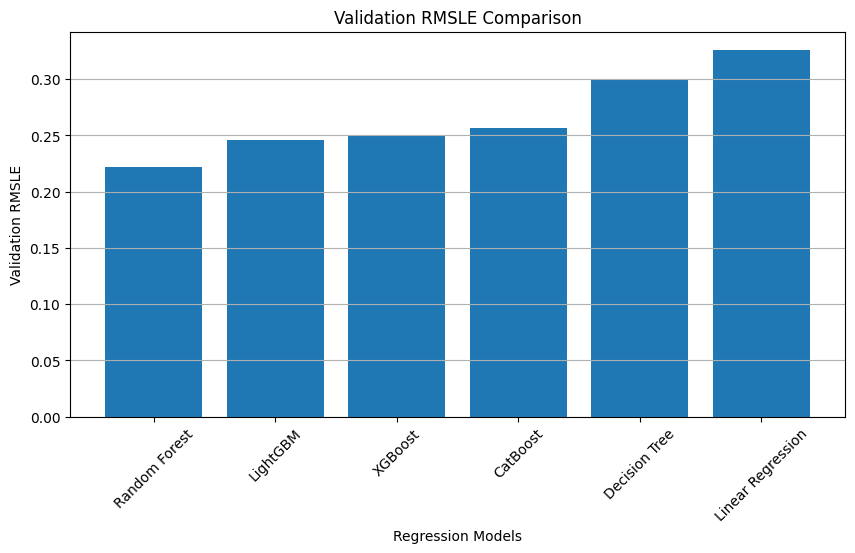

In [135]:
plt.figure(figsize=(10,5))

plt.bar(
    results_df["Model"],
    results_df["Validation RMSLE"]
)

plt.title("Validation RMSLE Comparison")

plt.xlabel("Regression Models")

plt.ylabel("Validation RMSLE")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.show()

**Model Selection:** Although Random Forest achieved the best baseline validation score, LightGBM was selected for further development because it provided comparable predictive performance with significantly lower training time, enabling faster hyperparameter tuning and rapid experimentation.

In [136]:
feature_names = tree_preprocessor.get_feature_names_out()

print(len(feature_names))

importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": lightgbm_model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(30)

731


,Feature,Importance
2,numerical__TransactionYear,262
4,numerical__AssetAge,213
0,numerical__ManufactureYear,163
728,high_cardinality__Spec_FullDescriptor,144
11,numerical__BaseClassFrequency,131
730,high_cardinality__ProductConfigID,112
18,numerical__ProductConfigYearCount,110
9,numerical__MissingFeatureCount,84
12,numerical__SubClassFrequency,80
729,high_cardinality__Spec_BaseClass,77


In [137]:
# Features with zero importance

zero_importance_features = (
    importance_df[
        importance_df["Importance"] == 0
    ]
    .sort_values("Feature")
)

print(f"Zero importance features : {len(zero_importance_features)}")

display(zero_importance_features)

Zero importance features : 543


,Feature,Importance
22,low_cardinality__DataOriginCode_ADI149,0
587,low_cardinality__DrivetrainType_AutoShift,0
588,low_cardinality__DrivetrainType_Autoshift,0
589,low_cardinality__DrivetrainType_Direct Drive,0
590,low_cardinality__DrivetrainType_Hydrostatic,0
...,...,...
605,low_cardinality__col8_High Profile,0
606,low_cardinality__col8_Low Profile,0
608,low_cardinality__col9_No,0
609,low_cardinality__col9_Variable,0


In [138]:
# zero_imp = zero_importance_features["Feature"].tolist()
# print(zero_imp)

In [139]:
importance_df[
    (importance_df["Importance"] < 20)
    &
    (
        importance_df["Feature"].str.startswith("numerical__")
        |
        importance_df["Feature"].str.startswith("high_cardinality__")
    )
].sort_values("Importance")

,Feature,Importance
16,numerical__DescriptorWordCount,0
5,numerical__HoursPerYear,7
17,numerical__MissingSpecCount,8
7,numerical__HasOperationalHours,12
14,numerical__AssetFrequency,13
8,numerical__HasVariantModifier,13
1,numerical__OperationalHoursMeter,17


# Hyperparameter Tuning

## Hyperparameter Tuning - LightGBM

Since the baseline LightGBM model achieved one of the best validation performance, a small number of carefully selected hyperparameter configurations are evaluated.

A manual search is preferred over an exhaustive grid search to obtain faster feedback while using the existing validation set as the model selection criterion.

In [140]:
def evaluate_lightgbm(

    num_leaves,
    learning_rate,
    n_estimators,
    max_depth,

    min_child_samples=20,
    feature_fraction=1.0,
    bagging_fraction=1.0,
    bagging_freq=0,
    lambda_l2=0.0

):
    model = LGBMRegressor(

    num_leaves=num_leaves,
    learning_rate=learning_rate,
    n_estimators=n_estimators,
    max_depth=max_depth,

    min_child_samples=min_child_samples,
    feature_fraction=feature_fraction,
    bagging_fraction=bagging_fraction,
    bagging_freq=bagging_freq,

    lambda_l2=lambda_l2,
        
    random_state=42,

    verbose = -1
)

    model.fit(

        X_train_tree,
        y_train

    )

    predictions_log = model.predict(X_valid_tree)

    predictions = np.expm1(predictions_log)
    
    actual = np.expm1(y_valid)
    
    predictions = np.maximum(predictions, 0)
    
    score = root_mean_squared_log_error(
        actual,
        predictions
    )

    print("-" * 60)

    print(f"Leaves        : {num_leaves}")
    print(f"Learning Rate : {learning_rate}")
    print(f"Estimators    : {n_estimators}")
    print(f"Max Depth     : {max_depth}")

    print(f"Lambda L2     : {lambda_l2}")

    print()

    print(f"Validation RMSLE : {score:.5f}")

    return score, model

In [141]:
#base model
baseline_score, baseline_lg_model = evaluate_lightgbm(

    num_leaves=31,
    learning_rate=0.1,
    n_estimators=100,
    max_depth=-1

)

------------------------------------------------------------
Leaves        : 31
Learning Rate : 0.1
Estimators    : 100
Max Depth     : -1
Lambda L2     : 0.0

Validation RMSLE : 0.24626


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [142]:
#best model from grid_search taken a further tuned manually
tuned_score, tuned_lg_model = evaluate_lightgbm(

    num_leaves=319,
    learning_rate=0.03,
    n_estimators=1200,
    max_depth=-1,

    min_child_samples=20,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    
    lambda_l2 = 3

)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


------------------------------------------------------------
Leaves        : 319
Learning Rate : 0.03
Estimators    : 1200
Max Depth     : -1
Lambda L2     : 3

Validation RMSLE : 0.20050


In [143]:
# Validation predictions from the final selected model
tuned_predictions_log = tuned_lg_model.predict(X_valid_tree)

tuned_predictions = np.expm1(tuned_predictions_log)

tuned_predictions = np.maximum(tuned_predictions, 0)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## Hyperparameter tuning LightGBM using GridSearchCV

In [144]:
# RMSLE scorer
def rmsle_score(y_true, y_pred):

    y_true = np.expm1(y_true)

    y_pred = np.expm1(y_pred)

    y_pred = np.maximum(y_pred, 0)

    return root_mean_squared_log_error(
        y_true,
        y_pred
    )

# Convert RMSLE into a scorer that GridSearchCV can optimize
rmsle_scorer = make_scorer(rmsle_score,greater_is_better=False)

In [145]:
# LightGBM param grid
param_grid = {

    "num_leaves": [255, 319],

    "learning_rate": [0.03],

    "n_estimators": [1000, 1200],

    "min_child_samples": [10, 20],

    "feature_fraction": [0.8],

    "bagging_fraction": [0.8],

    "lambda_l2": [2, 3]

}

In [146]:
# Base LightGBM Model
base_lightgbm_model = LGBMRegressor(

    random_state=42,
    verbose = -1,
    bagging_freq=5,
    max_depth=-1

)

In [147]:
# Grid Search
lg_grid_search = GridSearchCV(

    estimator=base_lightgbm_model,

    param_grid=param_grid,

    scoring=rmsle_scorer,

    cv=3,

    n_jobs=-1,

    verbose=1,

    refit=True

)


In [148]:
# Train
lg_grid_search.fit(

    X_train_tree,

    y_train

)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


GridSearchCV(cv=3,
             estimator=LGBMRegressor(bagging_freq=5, random_state=42,
                                     verbose=-1),
             n_jobs=-1,
             param_grid={'bagging_fraction': [0.8], 'feature_fraction': [0.8],
                         'lambda_l2': [2, 3], 'learning_rate': [0.03],
                         'min_child_samples': [10, 20],
                         'n_estimators': [1000, 1200],
                         'num_leaves': [255, 319]},
             scoring=make_scorer(rmsle_score, greater_is_better=False, response_method='predict'),
             verbose=1)

In [149]:
# Best Parameters
print("Best LightGBM Parameters:")
print(lg_grid_search.best_params_)

print()

print("Best LightGBM Cross Validation RMSLE:")
print(-lg_grid_search.best_score_)


Best LightGBM Parameters:
{'bagging_fraction': 0.8, 'feature_fraction': 0.8, 'lambda_l2': 2, 'learning_rate': 0.03, 'min_child_samples': 10, 'n_estimators': 1200, 'num_leaves': 319}

Best LightGBM Cross Validation RMSLE:
0.20785111324802563


In [150]:
# Best Model
best_lgbm = lg_grid_search.best_estimator_

In [151]:
# Validation Prediction
lg_predictions_log = best_lgbm.predict(X_valid_tree)

lg_predictions = np.expm1(lg_predictions_log)

actual = np.expm1(y_valid)

lg_predictions = np.maximum(lg_predictions, 0)

lg_score = root_mean_squared_log_error(

    actual,

    lg_predictions

)

print()

print("Validation RMSLE :", round(lg_score, 5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Validation RMSLE : 0.20078


## Final Model Selection

Both manual hyperparameter tuning and GridSearchCV converged to a very similar region of the LightGBM hyperparameter space.

GridSearchCV was performed using 3-fold cross-validation to identify a robust parameter combination, while manual tuning optimized performance on the split-out validation set used for validation score throughout model training.


|Hyperparameter|Manual|GridSearchCV|
| --- | --- | --- |
|num_leaves|319|319|
|learning_rate|0.03|0.03|
|n_estimators|1200|1200|
|min_child_samples|20|10|
|lambda_l2|3|2|
|feature_fraction|0.8|0.8|
|bagging_fraction|0.8|0.8|
|bagging_freq|5|5|
|max_depth|-1|-1|


Validation Performance (lower is better)

|Model|Validation RMSLE|
| --- | --- |
|Manual Tuned LightGBM|0.20050|
|GridSearchCV LightGBM|0.20078|


The difference between the two models was very small, indicating that both approaches converged to a similar optimal parameter set.

Although GridSearchCV identified a slightly different hyperparameter configuration, the manually tuned model achieved a marginally lower validation RMSLE on the split-out validation set. Therefore, the manually tuned configuration is selected as the final model and retrained on the complete training dataset before generating the competition submission.

# Validation Error Analysis

To better understand the selected model's behaviour, the validation predictions were compared with the actual selling prices. The largest prediction errors were examined to identify possible reasons incorrect predictions and future improvements.

In [152]:
# Best model predictions

best_predictions = tuned_predictions

In [153]:
validation_results = pd.DataFrame({

    "Actual": actual,

    "Predicted": best_predictions

})

#Absolute errors
validation_results["Absolute Error"] = np.abs(

    validation_results["Actual"] - validation_results["Predicted"]

)

#Percentage errors
validation_results["Percentage Error"] = (

    validation_results["Absolute Error"] / validation_results["Actual"]

) * 100
#rounding off percentage errors
validation_results["Percentage Error"] = validation_results["Percentage Error"].round(2)

## Error Summary Statistics

In [154]:
#summary statistics
validation_results[["Absolute Error", "Percentage Error"]].describe()

,Absolute Error,Percentage Error
count,27741.000000,27741.00000
mean,5316.468807,14.80383
std,5915.933202,18.06692
min,0.319433,0.00000
25%,1468.481779,4.86000
50%,3453.344950,10.48000
75%,7120.481497,19.28000
max,86359.688372,853.02000


## Scatter Plot

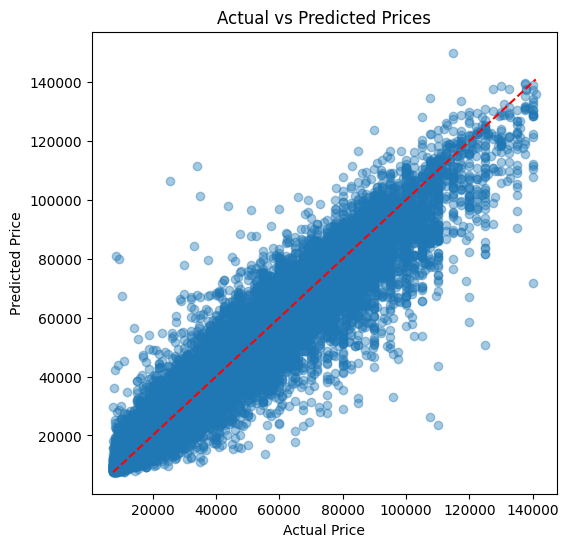

In [155]:
plt.figure(figsize=(6,6))

plt.scatter(

    validation_results["Actual"],
    validation_results["Predicted"],

    alpha=0.4

)

plt.plot(

    [validation_results["Actual"].min(),validation_results["Actual"].max()],

    [validation_results["Actual"].min(),validation_results["Actual"].max()],

    "r--"
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

plt.close()

## Largest Errors

In [156]:
largest_errors = validation_results.sort_values(

    by="Absolute Error",
    ascending=False

)

largest_errors.head(10)

,Actual,Predicted,Absolute Error,Percentage Error
111390,110000.0,23640.311628,86359.688372,78.51
78741,107500.0,26359.413894,81140.586106,75.48
70358,25500.0,106549.215692,81049.215692,317.84
70356,34000.0,111689.860410,77689.860410,228.50
116440,125000.0,50774.472134,74225.527866,59.38
79081,8500.0,81006.982875,72506.982875,853.02
37385,9500.0,79830.773604,70330.773604,740.32
73864,140000.0,71712.188946,68287.811054,48.78
66143,110000.0,43439.908562,66560.091438,60.51
79839,35000.0,101279.177447,66279.177447,189.37


Validation Error Analysis

The scatter plot compares the actual selling prices with the prices predicted by the manually tuned LightGBM model. The red dashed diagonal represents the ideal prediction line, where the predicted value is exactly equal to the actual value.

Most predictions lie close to this ideal line, indicating that the model is able to estimate machine prices with good overall accuracy. Although many predictions are not exact, they remain close approximations to the true selling prices, demonstrating that the model successfully captures the underlying relationship between the input features and the target variable.

A small number of observations lie farther from the diagonal, representing larger prediction errors and potential outliers. The accompanying summary statistics and largest-error table provide additional insight into these difficult predictions and highlight opportunities for further model improvement.

# Final Training model

After selecting the best hyperparameters using the train-validation split, the final model was retrained on the complete training dataset before generating predictions for the competition test set.

GridSearchCV confirmed that the manually identified hyperparameter region was close to optimal. The best cross-validation configuration differed only slightly from the manually tuned configuration. 

Since the manually tuned model achieved the best performance on the held-out validation set used throughout model development, it was selected as the final model

In [157]:
# Train Final Model on Complete Training Dataset
# ----------------------------------------------

# Fit preprocessing pipeline on the complete training dataset

X_full = X.copy()

X_full = engineer_features(X_full)
X_full = engineer_features2(X_full)

X_full = X_full.drop(columns=drop_features)

X_full_tree = tree_preprocessor.fit_transform(X_full)

y_full = y_log

# parameters same as manual tuned lightgbm model
final_model = LGBMRegressor(

    num_leaves=319,
    learning_rate=0.03,
    n_estimators=1200,
    max_depth=-1,

    min_child_samples=20,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,

    lambda_l2=3,

    random_state=42,
    verbose=-1

)

In [158]:
final_model.fit(

    X_full_tree,
    y_full

)

LGBMRegressor(bagging_fraction=0.8, bagging_freq=5, feature_fraction=0.8,
              lambda_l2=3, learning_rate=0.03, n_estimators=1200,
              num_leaves=319, random_state=42, verbose=-1)

In [159]:
X_test = test_df.copy()

X_test = engineer_features(X_test)
X_test = engineer_features2(X_test)

# Features to remove before preprocessing

X_test = X_test.drop(columns=drop_features)

X_test_tree = tree_preprocessor.transform(X_test)


# Test predictions using best model
test_predictions_log = final_model.predict(X_test_tree)

test_predictions = np.expm1(test_predictions_log)

test_predictions = np.maximum(test_predictions, 0)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


# Submission

In [160]:
submission = pd.DataFrame({
    "TransactionID": test_df["TransactionID"],
    "TargetValue": test_predictions
})

submission.to_csv("submission.csv", index=False)

print("Submission file saved successfully!")

Submission file saved successfully!


In [161]:
submission.head()

,TransactionID,TargetValue
0,1139307,69324.232438
1,1139419,75548.096334
2,1139482,35071.514783
3,1139522,20560.195289
4,1139684,12568.259290


In [162]:
submission.info()

submission.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TransactionID  15000 non-null  int64  
 1   TargetValue    15000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 234.5 KB


,TransactionID,TargetValue
count,1.500000e+04,15000.000000
mean,2.199650e+06,40836.345378
std,1.145245e+06,24805.508748
min,1.139307e+06,7183.643647
25%,1.468021e+06,20895.935858
50%,1.750341e+06,34663.355495
75%,2.372532e+06,56356.770740
max,6.333397e+06,136552.956904


In [163]:
sample.head()

,TransactionID,TargetValue
0,1139307,44674.9
1,1139419,91450.1
2,1139482,76618.1
3,1139522,75195.6
4,1139684,8340.3


In [164]:
sample.info()

sample.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TransactionID  15000 non-null  int64  
 1   TargetValue    15000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 234.5 KB


,TransactionID,TargetValue
count,1.500000e+04,15000.000000
mean,2.199650e+06,49938.738407
std,1.145245e+06,28852.255200
min,1.139307e+06,2.600000
25%,1.468021e+06,24981.450000
50%,1.750341e+06,50196.500000
75%,2.372532e+06,74903.975000
max,6.333397e+06,99991.100000


# Future Improvements

1. Hyperparameter Tuning of Additional Models
   - Given more computational time, we can perform GridSearchCV for Random Forest and other baseline models to compare their fully optimized performance against LightGBM.
2. Additional Feature Engineering
   - Convert the remaining three partially usable columns into numerical features and evaluate whether they improve model performance.
3. Model Ensembling
   - Combine predictions from tuned LightGBM, CatBoost, and XGBoost to potentially improve generalization and competition performance.
4. More Comprehensive Error Analysis
   - Investigate prediction errors across different machine categories, age groups, and price ranges to identify find patterns in weaknesses.
5. Extended Cross-Validation
   - Evaluate model robustness using additional validation strategies and compare performance across different train-validation splits.

# Appendix A — Milestone Development

The following sections contain the milestone work completed during the project.
They are retained as a record of project progression.

The main project notebook is above this appendix.

# Exploratory Data Analysis (EDA)

*What does this tell me about the data?*

## TargetValue Median

The median selling price is **$35,000**.

**Median** is preferred over the **mean** value when analysing heavy equipment prices because transaction values are often right-skewed. A small number of highly expensive equipement can substantially increase the average(mean) price, whereas the median better represents *the typical transaction amount* in this dataset.

#### Note:
*Heavy machinery prices* are often **right-skewed**.


In [165]:
# train_df["TargetValue"].median()

## Manufacture Year Anomaly
 When analyzing the `ManufactureYear` feature column a strange anomaly was found. 
 
 The most frequently occurring (mode) ManufactureYear in the dataset, indicates a default placeholder value used by the data entry system

In [166]:
# train_df["ManufactureYear"].mode()

The **most frequently occurring** value in the `ManufactureYear` column is **1001**?
This almost certainly seems like a placeholder/default value inserted by some data entry system whenever the actual year was unknown.

## Time Span of Transactions
The earliest (minimum) `TransactionDate` recorded in the training dataset:

In [167]:
# train_df["TransactionDate"].min()

The latest (maximum) `TransactionDate` recorded in the training dataset:

In [168]:
# train_df["TransactionDate"].max()

The time span of selling price dataset we have is:

- **1990-01-31** to **2013-04-28**

## Missing Value Analysis

### Training Dataset

#### Missing values per column

In [169]:
# train_df.isna().sum()

#### Columns with most values missing

In [170]:
# missing_train_df = pd.DataFrame({
    
#     "Missing_Count": train_df.isna().sum(),
#     "Missing_Percent": (train_df.isna().sum() / len(train_df)) * 100

# # })

# missing_train_df = missing_train_df.sort_values(by="Missing_Percent",ascending=False)

In [171]:
# high_missing_cols = missing_train_df[missing_train_df["Missing_Percent"] > 90]
# high_missing_cols

In [172]:
# high_missing_cols.index.tolist()

#### Observations

The following columns contain more than 90% missing values:

- col18  (with missing count: **138635/138,701**)
- col19  (with missing count: **138635/138,701**)
- col5   (with missing count: **128320/138,701**)
- col4   (with missing count: **128320/138,701**)

These features provide information for only a very small subset of records.
Such columns may introduce noise and increase model complexity.

Potential actions to proceed in feature engineering later:

1. Drop these columns entirely.
2. Group rare categories into "Other" as a new feature.
3. Create missing-indicator features if domain-relevant information is present in these feature columns.

For now, no columns are being removed during the basic overview.

## OperationalHoursMeter Feature Missing Values

The `OperationalHoursMeter` feature represents the lifetime active runtime of the machine.
The approximate percentage of missing values for this critical column in the training dataset is relevant information

In [173]:
# #percentage of missing values from the OperationalHoursMeter Feature in the training dataset


# ohm_missing = train_df["OperationalHoursMeter"].isna().sum()
# ohm_present = train_df["OperationalHoursMeter"].count()
# ohm_total = len(train_df)


# missing_ohm_pt = (ohm_missing/ohm_total * 100)

# # this feature has boolean values, so mean() returns the fraction of missing values to total values in the dataset directly and can be used here as well
# # train_df["OperationalHoursMeter"].isna().mean() * 100

# print(f"{missing_ohm_pt:.2f}%")

The `OperationalHoursMeter`feature contains approximately **40.84% missing values**.

Since this variable represents machine usage and is likely to be of predictive importance to selling price, it should not be dropped despite the substantial missing value count.

Preprocessing is required for this feature column, which could include the following:
- Median imputation
- Group-wise imputation
- Missing indicator feature
- Model-based imputation

## Identifying Sparse Features

In [174]:
# # Identify columns with more than 80% missing values

# missing_percentage = train_df.isnull().mean() * 100

# sparse_columns = missing_percentage[missing_percentage > 80]

# print("Columns with >80% missing values:")
# print(sparse_columns)

# print("\nNumber of columns to drop:", len(sparse_columns))

## High Cardinality Features Identification
Machine learning models struggle with high-cardinality categorical features.
Let us find which features have the most high-cardinality features:

In [175]:
# # Count unique values for all categorical columns
# cardinality = train_df.select_dtypes(include=['object','category']).nunique()

# # Filter columns where unique values exceed your threshold (e.g., 50)
# high_cardinal_features = cardinality[cardinality > 50].index.tolist()

# high_cardinal_features.sort(reverse = True)

# high_cardinal_features

Now let us find the unique string classes existing within the `Spec_BaseClass` column:

In [176]:
# train_df["Spec_BaseClass"].nunique()

## Geographical Volume 
The regions accounting for the highest volume of machinery transactions (RegionCode) in this dataset:

In [177]:
# train_df["RegionCode"].value_counts().head(10)

## Regional Pricing Insights
The most frequent region that is identified as Florida, the approximate average TargetValue for machines sold there is relevant information:

Average TargetValue for every region:

In [178]:
# train_df.groupby("RegionCode")["TargetValue"].mean().sort_values(ascending = False)

Average `TargetValue` for ***Most Frequent Region* i.e. **Florida** is:

In [179]:
# florida_avg = train_df.loc[train_df["RegionCode"] == "Florida","TargetValue"].mean()

# florida_avg

## Asset Utilization 
The `UtilizationTier` metadata column ranks how heavily an asset was used.

Based on the value counts in the training set, Let's find the most common **utilization tier**:

In [180]:
# train_df["UtilizationTier"].value_counts(dropna=False)

## Operational Correlation

Intuitively, one might assume that machines with higher `OperationalHoursMeter` values would sell for less.
But the **Pearson correlation coefficient** between **TargetValue** and **OperationalHoursMeter** tells us the real story between these features:

In [181]:
# train_df["TargetValue"].corr(train_df["OperationalHoursMeter"])

A correlation between these features (`TargetValue` and `OperationalHoursMeter`) being **~ 0.002** is virtually **zero correlation**.

## Primary Equipment Types 
Based on the `FunctionalClassification` column, the description of the single most common exact machinery traded on this platform is:

In [182]:
# # train_df["FunctionalClassification"].value_counts().head()
# train_df["FunctionalClassification"].mode()[0]

# Data Quality Assessment

## Numerical Features

In [183]:
# train_df.select_dtypes(include=['float64','int64'])

In [184]:
# train_df.select_dtypes(include='number')

In [185]:
# train_df.select_dtypes(include='number').count().count()

# Feature Engineering

First, we convert our `transaction date` feature into a datetime pandas object.
(`pd.to_datetime()` function converts strings, integers, lists, or Series into standardized pandas datetime objects (datetime64))

In [186]:
# # Convert to datetime
# train_df["TransactionDate"] = pd.to_datetime(train_df["TransactionDate"])
# test_df["TransactionDate"] = pd.to_datetime(test_df["TransactionDate"])

## New Features

In [187]:
# # New features

# # TransactionYear [Extracted from TrasactionDate]
# train_df["TransactionYear"] = train_df["TransactionDate"].dt.year
# test_df["TransactionYear"] = test_df["TransactionDate"].dt.year


In [188]:
# # TransactionQuarter [Extract from TransactionDate]
# train_df["TransactionQuarter"] = train_df["TransactionDate"].dt.quarter
# test_df["TransactionQuarter"] = test_df["TransactionDate"].dt.quarter



In [189]:
# # AssetAge [TansactionYear - ManufactureYear]
# train_df["AssetAge"] = (train_df["TransactionYear"] - train_df["ManufactureYear"])
# test_df["AssetAge"] = (test_df["TransactionYear"] - test_df["ManufactureYear"])


In [190]:
# # DescriptorLength [Stores the number of characters in Spec_FullDescriptor]
# train_df["DescriptorLength"] = train_df["Spec_FullDescriptor"].str.len()
# test_df["DescriptorLength"] = test_df["Spec_FullDescriptor"].str.len()



In [191]:
#  # HasOperationalHours [ A binary feature. Assign 1 if OperationalHoursMeter is available. Assign 0 otherwise]
# train_df["HasOperationalHours"] = train_df["OperationalHoursMeter"].notna().astype(int)
# test_df["HasOperationalHours"] = test_df["OperationalHoursMeter"].notna().astype(int)

# # Note: this feature is of predictive importance, like discussed before, hence we do not remove it.
# # We instead engineer a new feature out of it.

In [192]:
# # HasVariantModifier [ A binary feature. Assign 1 if Spec_VariantModifier is available. Assign 0 otherwise.]
# train_df["HasVariantModifier"] = train_df["Spec_VariantModifier"].notna().astype(int)
# test_df["HasVariantModifier"] = test_df["Spec_VariantModifier"].notna().astype(int)

In [193]:
# print("Q1: AssetAge occuring most frequently in the training dataset")
# print(train_df["AssetAge"].mode())

# print("\nQ2: TransactionQuarter that has the highest average TargetValue")
# print(train_df.groupby("TransactionQuarter")["TargetValue"].mean())

# print("\nQ3: maximum value of DescriptorLength in the training dataset")
# print(train_df["DescriptorLength"].max())

# print("\nQ4: number of records that have HasOperationalHours = 1 in training data? (NAT)")
# print(train_df["HasOperationalHours"].sum())

# print("\nQ5: percentage of records containing variant information in training data")
# print((train_df["HasVariantModifier"].mean()*100).round(4))

# print("\nQ6: mean of ManufactureYear in the training data(Round to 2 decimal places")
# print(round(train_df["ManufactureYear"].mean(),2))

In [194]:
# ## Datetime Extraction
# # Ensure TransactionDate is in datetime format
# train_df["TransactionDate"] = pd.to_datetime(train_df["TransactionDate"])
# test_df["TransactionDate"] = pd.to_datetime(test_df["TransactionDate"])

# # Extract SaleYear
# train_df["SaleYear"] = train_df["TransactionDate"].dt.year
# test_df["SaleYear"] = test_df["TransactionDate"].dt.year

# # Most frequent SaleYear
# saleyear_mode = train_df["SaleYear"].mode()[0]

# print("Most Frequent SaleYear:", saleyear_mode)

## Manufacture year anomaly fixing

In [195]:
# # Replace invalid manufacture years with NaN

# train_df["ManufactureYear"] = train_df["ManufactureYear"].replace([1000, 1001], np.nan)
# test_df["ManufactureYear"] = test_df["ManufactureYear"].replace([1000, 1001], np.nan)

## Asset Age Calculation

In [196]:
# # Create corrected AssetAge
# train_df["AssetAge"] = train_df["SaleYear"] - train_df["ManufactureYear"]
# test_df["AssetAge"] = test_df["SaleYear"] - test_df["ManufactureYear"]

# # Median AssetAge
# asset_age_median = train_df["AssetAge"].median()

# print(f"Median AssetAge: {asset_age_median:.2f}")

# Feature Interaction (HoursPerYear)

In [197]:
# # Create usage intensity feature

# train_df["HoursPerYear"] = (
#     train_df["OperationalHoursMeter"] / train_df["AssetAge"]
# )

# test_df["HoursPerYear"] = (
#     test_df["OperationalHoursMeter"] / test_df["AssetAge"]
# )

# # Remove infinite values caused by zero AssetAge
# train_df["HoursPerYear"] = train_df["HoursPerYear"].replace([np.inf, -np.inf], np.nan)
# test_df["HoursPerYear"] = test_df["HoursPerYear"].replace([np.inf, -np.inf], np.nan)

# # Median usage intensity
# hours_per_year_median = train_df["HoursPerYear"].median()

# print(f"Median HoursPerYear: {hours_per_year_median:.2f} hours/year")

# Encoding

## One-Hot-Encoding

**OneHotEncoding (Use drop_first=True)** on categorical features:
- `RegionCode`
- `CabinType`
- `UtilizationTier`

In [198]:
# encoded_train = pd.get_dummies(
#     train_df,
#     columns=[
#         "RegionCode",
#         "CabinType",
#         "UtilizationTier"
#     ],
#     drop_first=True
# )

# encoded_test = pd.get_dummies(
#     test_df,
#     columns=[
#         "RegionCode",
#         "CabinType",
#         "UtilizationTier"
#     ],
#     drop_first=True
# )

# print(encoded_train.shape)

In [199]:
# for col in ["RegionCode", "CabinType", "UtilizationTier"]:
#     print(f"{col}: {train_df[col].nunique(dropna=False)}")

encoded columns created in the training data after applying One-Hot Encoding to these three features is:

In [200]:
# len(encoded_train.columns) - len(train_df.columns)

## Ordinal Encoding

In [201]:
# from sklearn.preprocessing import OrdinalEncoder

# # Create a temporary copy
# temp_df = train_df.copy()

# # Apply Ordinal Encoding
# encoder = OrdinalEncoder()

# temp_df["UtilizationTier_Encoded"] = encoder.fit_transform(
#     temp_df[["UtilizationTier"]]
# )

# # Display learned categories
# print("Categories:", encoder.categories_[0])

# # Number of unique encoded values
# print("Unique encoded values:",
#       temp_df["UtilizationTier_Encoded"].nunique())

# Correlation Analysis

following numerical features has the highest absolute correlation with TargetValue in the training data:

In [202]:
# numeric_cols = train_df.select_dtypes(include=["int64","float64"])

# corr = numeric_cols.corr()["TargetValue"].abs().sort_values(ascending=False)

# corr

### Correlation with Target Variable

Rather than inspecting the complete correlation matrix, the correlations of all numerical features with the target variable are extracted, converted to absolute values, and sorted in descending order.

This provides a concise ranking of the strongest linear relationships with the target and helps identify promising predictors for baseline models.

In [203]:
# target_corr = (
#     train_df
#     .select_dtypes(include=["number"])
#     .corr()["TargetValue"]
#     .drop("TargetValue")
#     .abs()
#     .sort_values(ascending=False)
# )

# target_corr

In [204]:
# print(target_corr.index[0])
# print(target_corr.iloc[0])

In [205]:
# target_corr.idxmax()

In [206]:
# target_corr.max()

# Imputing Missing Numeric Data

In [207]:
# # Impute skewed numerical feature using median

# hours_median = train_df["OperationalHoursMeter"].median()

# train_df["OperationalHoursMeter"] = train_df["OperationalHoursMeter"].fillna(hours_median)
# test_df["OperationalHoursMeter"] = test_df["OperationalHoursMeter"].fillna(hours_median)

# print(f"Median OperationalHoursMeter used for imputation: {hours_median:.2f}")

# Imputing Missing Categorical Data

In [208]:
# # Fill missing values in CabinType

# train_df["CabinType"] = train_df["CabinType"].fillna("Missing")
# test_df["CabinType"] = test_df["CabinType"].fillna("Missing")

# # Count rows containing "Missing"
# missing_cabin_count = (train_df["CabinType"] == "Missing").sum()

# print(f'Rows with CabinType = "Missing": {missing_cabin_count}')

In [209]:
# print(train_df["CabinType"].value_counts(dropna=False).head(20))

In [210]:
# print(train_df["CabinType"].isna().sum())

Let's try that on the raw training dataset

In [211]:
# # Reload original training data (temporary cell for milestone calculation)

# raw_train = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv",low_memory=False)

# print("Original missing CabinType values:")
# print(raw_train["CabinType"].isna().sum())

In [212]:
# raw_train["CabinType"] = raw_train["CabinType"].fillna("Missing")

# print((raw_train["CabinType"] == "Missing").sum())

In [213]:
# print(raw_train["CabinType"].unique())
# print(raw_train["CabinType"].value_counts(dropna=False))

# Train-Test Split Verification

In [214]:
# # Define features and target

# X = train_df.drop(columns=["TargetValue"])
# y = train_df["TargetValue"]

# # Train-validation split (80/20)

# from sklearn.model_selection import train_test_split

# X_train, X_valid, y_train, y_valid = train_test_split(
#     X,
#     y,
#     test_size=0.20,
#     random_state=42
# )

In [215]:
# print("X_train shape:", X_train.shape)

# print("X_valid shape:", X_valid.shape)

# Feature Scaling

In [216]:
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import train_test_split

# features = [
#     "ManufactureYear",
#     "OperationalHoursMeter",
#     "AssetAge"
# ]

# X = train_df[features]
# y = train_df["TargetValue"]

# imputer = SimpleImputer(strategy="mean")
# X = imputer.fit_transform(X)

# scaler = StandardScaler()
# X = scaler.fit_transform(X)

# X_train, X_val, y_train, y_val = train_test_split(
#     X,
#     y,
#     test_size=0.2,
#     random_state=42
# )

# print(X_train.shape)
# print(X_val.shape)

In [217]:
# processed_train = encoded_train.copy()

In [218]:
# scale_cols = [
#     "ManufactureYear",
#     "OperationalHoursMeter",
#     "AssetAge"
# ]

# imputer = SimpleImputer(strategy="mean")

# processed_train[scale_cols] = imputer.fit_transform(
#     processed_train[scale_cols]
# )

# scaler = StandardScaler()

# processed_train[scale_cols] = scaler.fit_transform(
#     processed_train[scale_cols]
# )

In [219]:
# X = processed_train.drop("TargetValue", axis=1)
# y = processed_train["TargetValue"]

In [220]:
# X_train, X_val, y_train, y_val = train_test_split(
#     X,
#     y,
#     test_size=0.2,
#     random_state=42
# )

# print(X_train.shape)
# print(X_val.shape)

In [221]:
# processed_train.shape

In [222]:
# X.shape

In [223]:
# print(train_df.columns.tolist())

In [224]:
# processed_train.dtypes.value_counts()

In [225]:
# processed_train.select_dtypes(include="number").shape

In [226]:
# processed_train.select_dtypes(
#     include=["number", "bool"]
# ).shape

# Train-Test Split

In [227]:
# X = train_df.copy()

# # Impute and scale only these columns
# cols = ["ManufactureYear", "OperationalHoursMeter", "AssetAge"]

# imputer = SimpleImputer(strategy="mean")
# X[cols] = imputer.fit_transform(X[cols])

# scaler = StandardScaler()
# X[cols] = scaler.fit_transform(X[cols])

# # Remove target
# X = X.drop(columns="TargetValue")

# X_train, X_val, y_train, y_val = train_test_split(
#     X,
#     y,
#     test_size=0.2,
#     random_state=42
# )

# print(X_train.shape)
# print(X_val.shape)

# Log Transforming the TargetValue Column

In [228]:
# train_df["LogTargetValue"] = np.log1p(train_df["TargetValue"])

# log_target_std = train_df["LogTargetValue"].std()

# print(f"Standard deviation after log1p transformation: {log_target_std:.2f}")

# Model Building

In [229]:
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import r2_score

# # Use only required predictors
# X = train_df[["ManufactureYear","AssetAge"]]

# X = SimpleImputer(strategy="mean").fit_transform(X)
# X = StandardScaler().fit_transform(X)

# X_train, X_val, y_train, y_val = train_test_split(
#     X,
#     y,
#     test_size=0.2,
#     random_state=42
# )

# model = LinearRegression()
# model.fit(X_train,y_train)

In [230]:
# preds = model.predict(X_val)

# print(r2_score(y_val,preds))

# Dummy Submission

**float64**:

- TargetValue
- OperationalHoursMeter

**int64**:

- TransactionID
- AssetID
- ProductConfigID
- ManufactureYear

`4 int64 + 2 float64 = 6`

the dataset contains total of **6** strictly numerical features

In [231]:
# #separating feature and target columns
# target = "TargetValue"

# X = train_df.drop(columns=[target])
# y = train_df[target]

# #train-test-split and random state setting
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# #initializing and fitting the dummy regressor
# dummy = DummyRegressor(strategy="median")
# dummy.fit(X_train, y_train)

# # Because RMSLE can be sensitive to outliers, 
# # and median is often slightly more robust than mean, even for a dummy baseline.

# #predictions on validation split
# preds = dummy.predict(X_val)

# #evaluation
# r2=r2_score(y_val, preds)

# print("Dummy R2 Score:", r2)

In [232]:
# prediction on test dataset
# test_preds = dummy.predict(test_df)

# Submission of dummy model predictions

In [233]:
# #Submission of dummy file
# submission = pd.DataFrame({
#     "TransactionID": test_df["TransactionID"],
#     "TargetValue": test_preds
# })

# submission.to_csv("submission.csv", index=False)

# Submission evaluation

We check our submission file created programmatically, `submission.csv` against the `sample_submission.csv` file provided. 

In [234]:
# sample = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv")
# sample.head()

In [235]:
# submit_file = pd.read_csv("/kaggle/working/submission.csv")
# submit_file.head()

The submission file is correctly formatted and ready for submission